# Phase 8: Regime Characterization

Characterize ensemble regimes using statistical analysis, visualizations, and transition dynamics to understand regime properties and market behavior.

## Steps:
1. Load ensemble regimes (2000-2020) and merge with market indicators
2. Compute comprehensive regime statistics (mean, std, median, quartiles) for each indicator
3. Perform ANOVA tests to validate statistical significance of regime differences
4. Visualize regime characteristics: boxplots by indicator and standardized heatmap
5. Analyze regime timeline across full period (2000-2020) 
6. Compute transition matrix and regime persistence probabilities
7. Analyze regime duration statistics and distributions
8. Generate comprehensive visualizations: timeline, transitions, and durations
9. Save all regime characterization outputs for final analysis


## 1. Data Loading and Preparation


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore')

# Add project root to path
sys.path.append(str(Path('..').resolve()))

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Define regime labels and colors for consistency
REGIME_LABELS = {0: "Calm", 1: "Moderate", 2: "Turbulent"}
REGIME_COLORS = {"Calm": "#2ecc71", "Moderate": "#f39c12", "Turbulent": "#e74c3c"}


### 1.1. Load Ensemble Regimes


In [87]:
# Load ensemble regimes from Phase 7
ensemble_path = Path('../data/processed/ensemble_regimes.csv')
df_regimes = pd.read_csv(ensemble_path, index_col=0, parse_dates=True)

### 1.2. Load Market Indicators


In [88]:
# Load best subset features with all market indicators
features_path = Path('../data/processed/best_subset_features.csv')
df_features = pd.read_csv(features_path, index_col=0, parse_dates=True)

# Drop market_correlation if present (computed from subset returns)
df_features = df_features.drop(columns=['market_correlation'], errors='ignore')
df_features = df_features.dropna()

# Get indicator columns
INDICATOR_COLS = [col for col in df_features.columns]

print(f"Loaded {len(df_features)} observations from {df_features.index.min().date()} to {df_features.index.max().date()}")
print(f"Indicators ({len(INDICATOR_COLS)}): {INDICATOR_COLS}")
df_features.head()


Loaded 5174 observations from 1999-09-09 to 2020-04-01
Indicators (8): ['market_direction', 'market_volume', 'market_volatility', 'market_breadth', 'market_atr', 'Subset_Trend_PC1', 'Subset_Stress_PC2', 'Subset_Risk_Score']


,market_direction,market_volume,market_volatility,market_breadth,market_atr,Subset_Trend_PC1,Subset_Stress_PC2,Subset_Risk_Score
Date,,,,,,,,
1999-09-09,0.044481,0.668554,-0.439347,-0.360368,-1.458618,0.019368,-0.844108,-0.863476
1999-09-10,0.373123,-0.542942,-0.421970,0.098987,-1.494984,0.588881,-0.784383,-1.373263
1999-09-13,-0.347303,-0.076524,-1.015642,-0.245594,-1.564552,-0.049524,-1.366564,-1.317041
1999-09-14,0.075162,1.332306,0.383784,-1.295129,-1.425592,-0.651243,-0.683804,-0.032561
1999-09-15,-0.277341,-1.236448,-0.459248,-1.051859,-1.377801,-0.611306,-1.159525,-0.548219


### 1.3. Merge and Validate Data


In [89]:
# Merge regimes with features on date index
df = df_regimes[['regime', 'regime_label']].join(df_features, how='inner')

# Validation checks
assert df['regime'].isin([0, 1, 2]).all(), "Regime values must be in {0, 1, 2}"
assert df.index.is_monotonic_increasing, "Index must be sorted"
assert df.index.is_unique, "Index must be unique"
assert df.isnull().sum().sum() == 0, f"Found {df.isnull().sum().sum()} missing values"


## 2. Compute Regime Statistics


In [90]:
# Compute statistics for each regime and indicator
stats_list = []

for regime in sorted(df['regime'].unique()):
    regime_label = REGIME_LABELS[regime]
    regime_data = df[df['regime'] == regime]
    
    for indicator in INDICATOR_COLS:
        values = regime_data[indicator].dropna()
        
        stats_list.append({
            'regime': regime,
            'regime_label': regime_label,
            'indicator': indicator,
            'count': len(values),
            'mean': values.mean(),
            'std': values.std(),
            'median': values.median(),
            'q25': values.quantile(0.25),
            'q75': values.quantile(0.75)
        })

df_stats = pd.DataFrame(stats_list)

# Save statistics
stats_path = Path('../results/tables/regime_statistics.csv')
df_stats.to_csv(stats_path, index=False)


## 3. Statistical Validation (ANOVA)


In [91]:
# Run ANOVA for each indicator
anova_results = []

for indicator in INDICATOR_COLS:
    # Get data for each regime
    regime_0 = df[df['regime'] == 0][indicator].dropna()
    regime_1 = df[df['regime'] == 1][indicator].dropna()
    regime_2 = df[df['regime'] == 2][indicator].dropna()
    
    # Perform one-way ANOVA
    f_stat, p_value = f_oneway(regime_0, regime_1, regime_2)
    
    anova_results.append({
        'indicator': indicator,
        'f_stat': f_stat,
        'p_value': p_value,
        'significant': p_value < 0.05
    })

df_anova = pd.DataFrame(anova_results)

# Save ANOVA results
anova_path = Path('../results/tables/regime_anova.csv')
df_anova.to_csv(anova_path, index=False)

## 4. Visualizations

### Figure 1: Boxplots by Regime


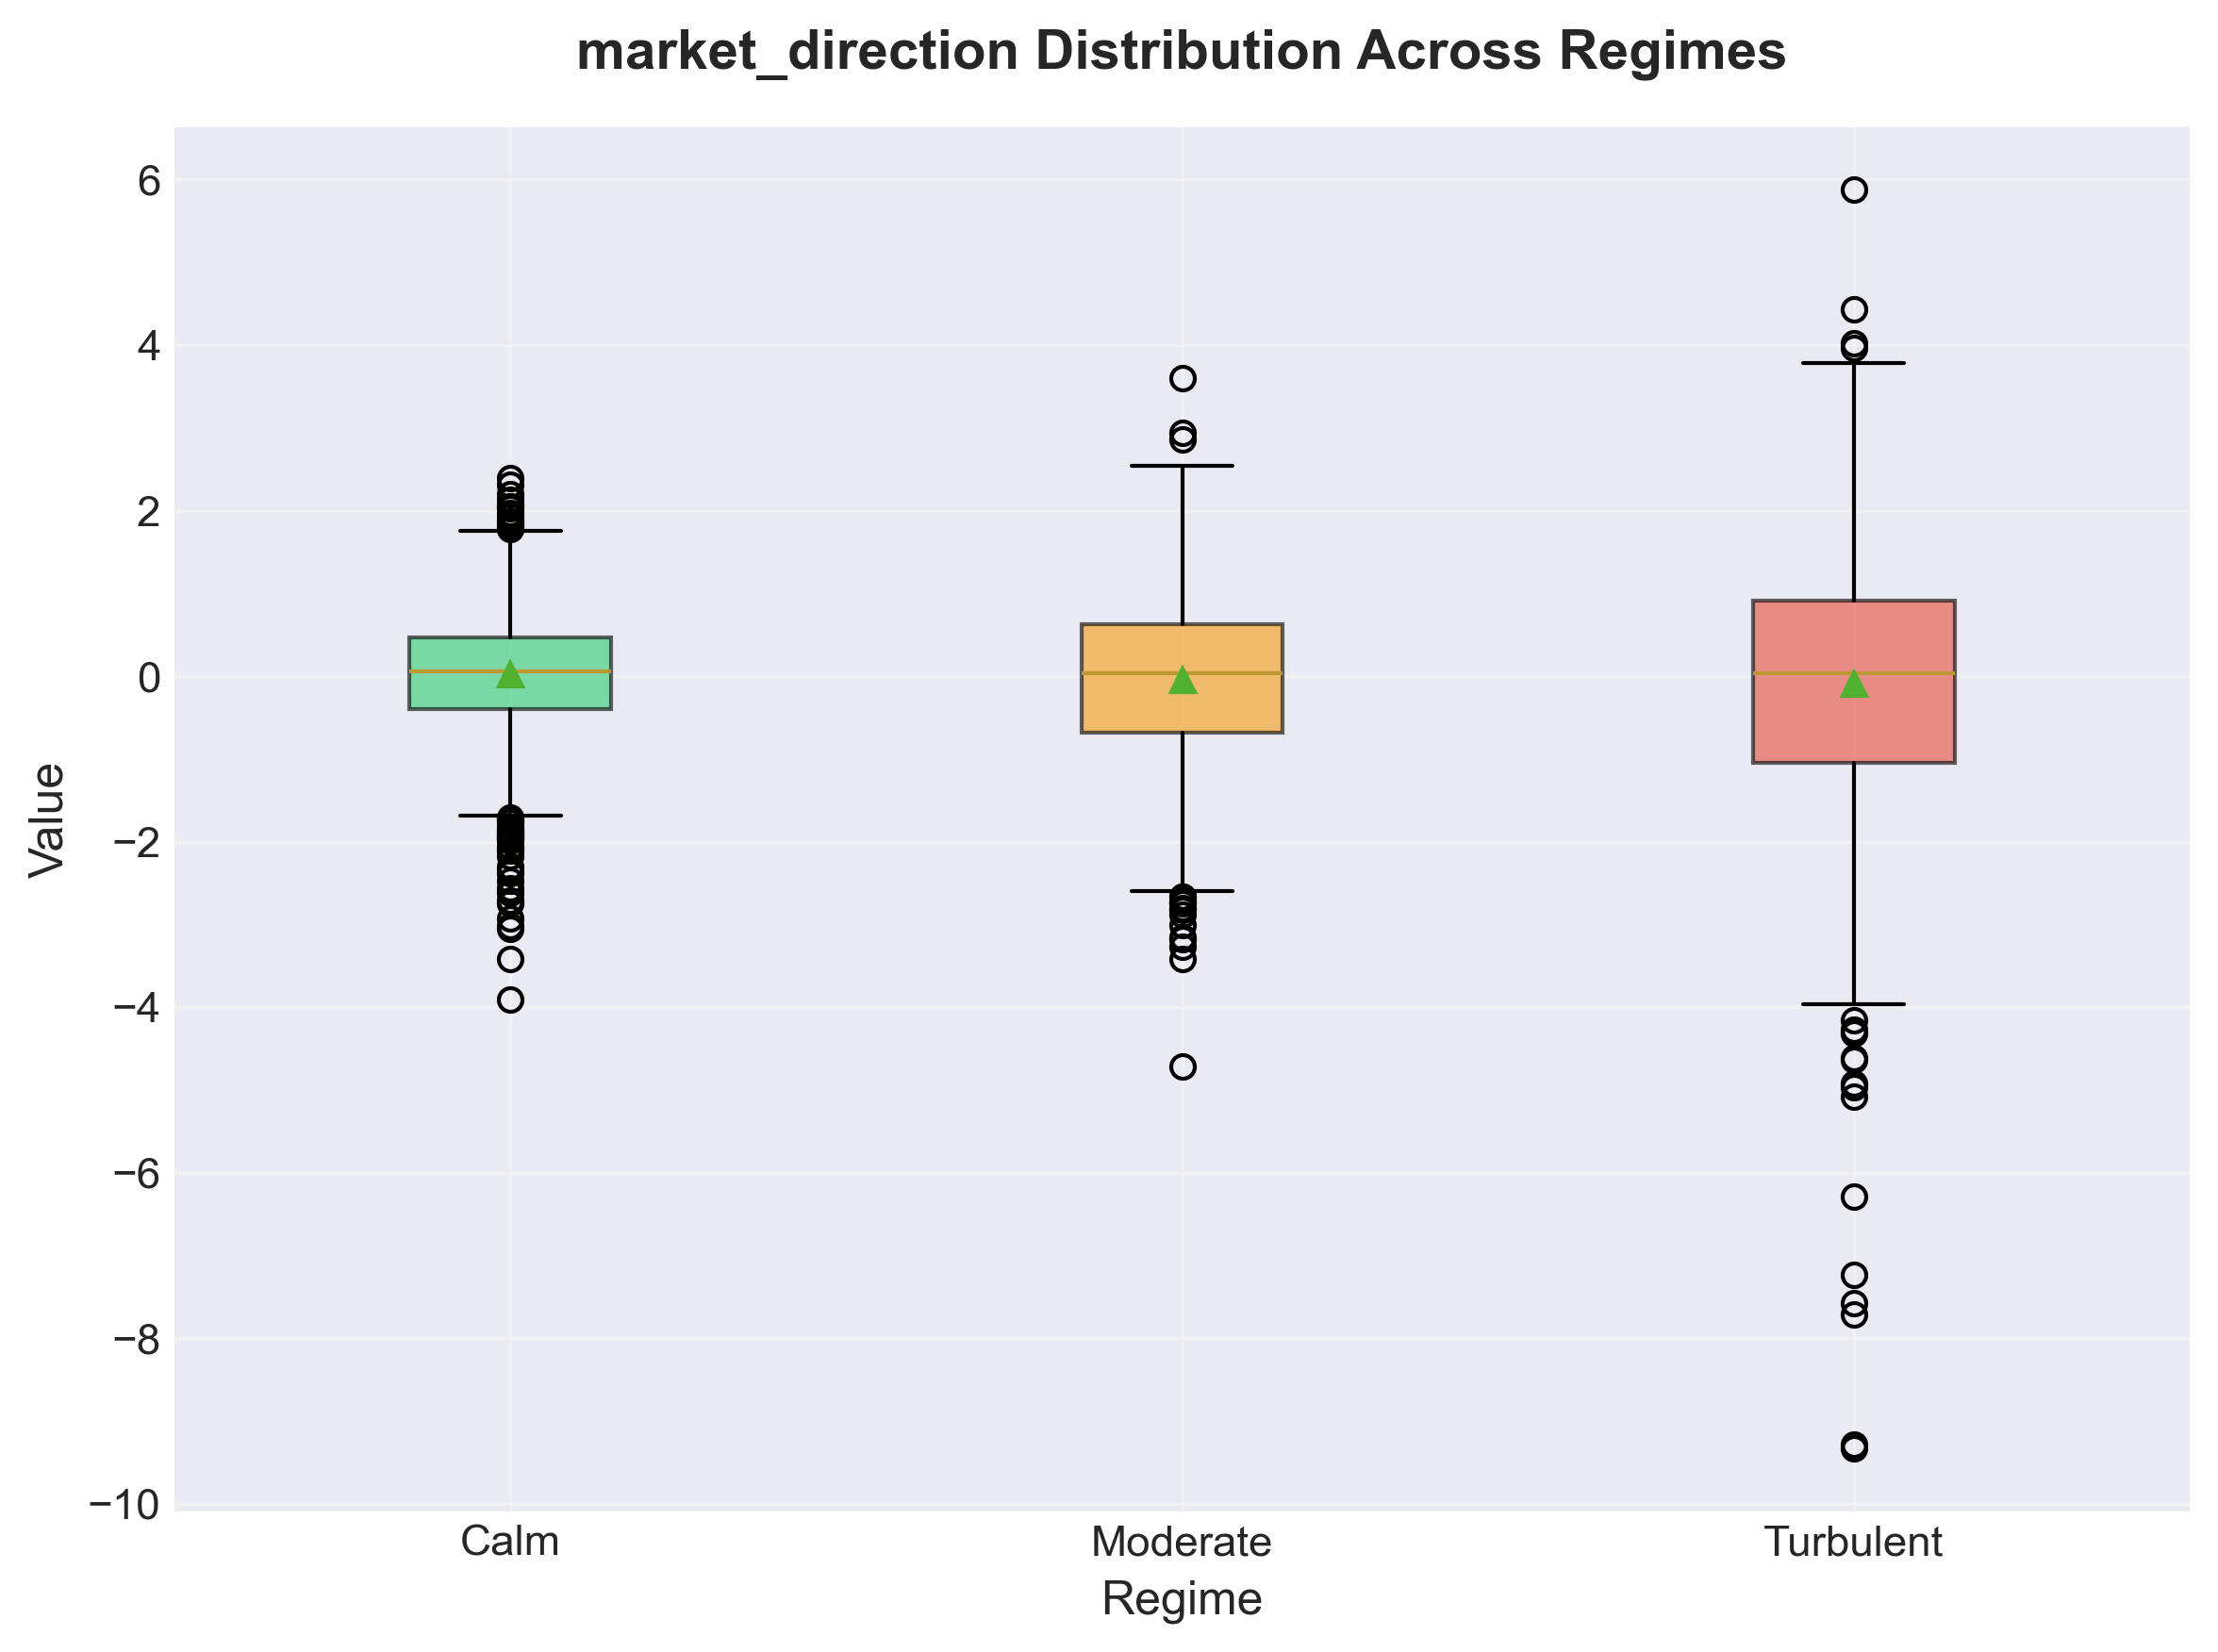

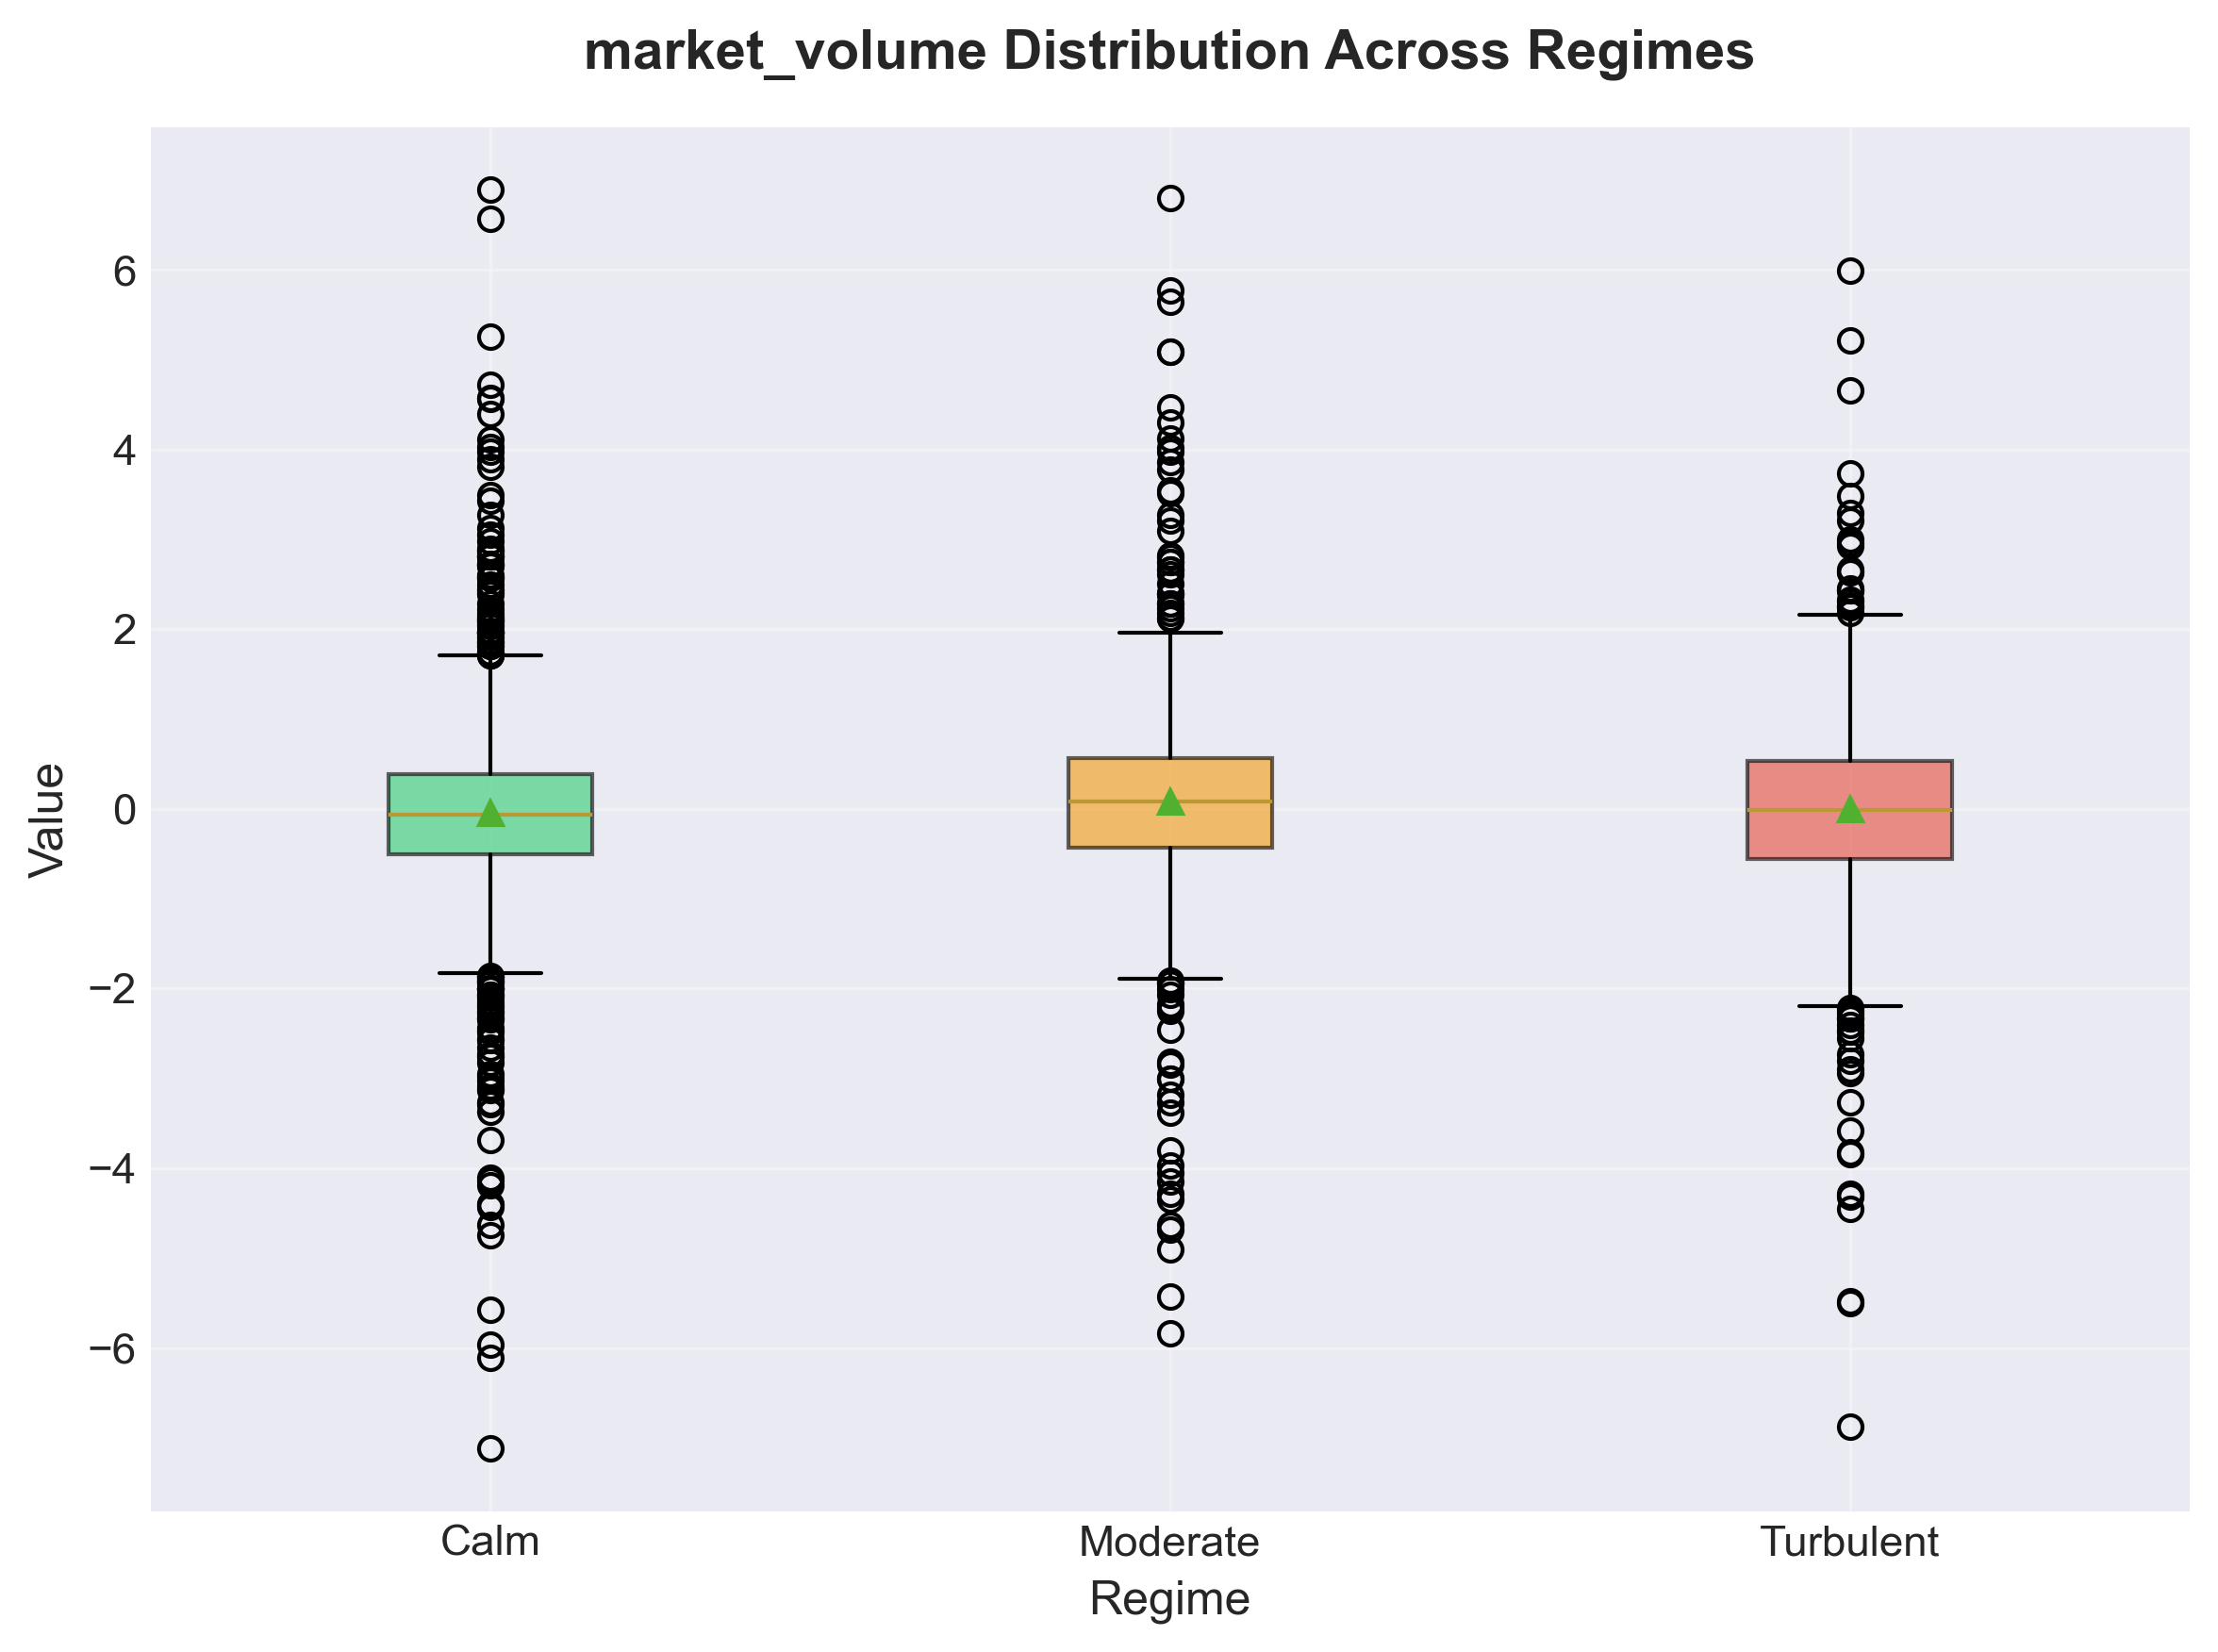

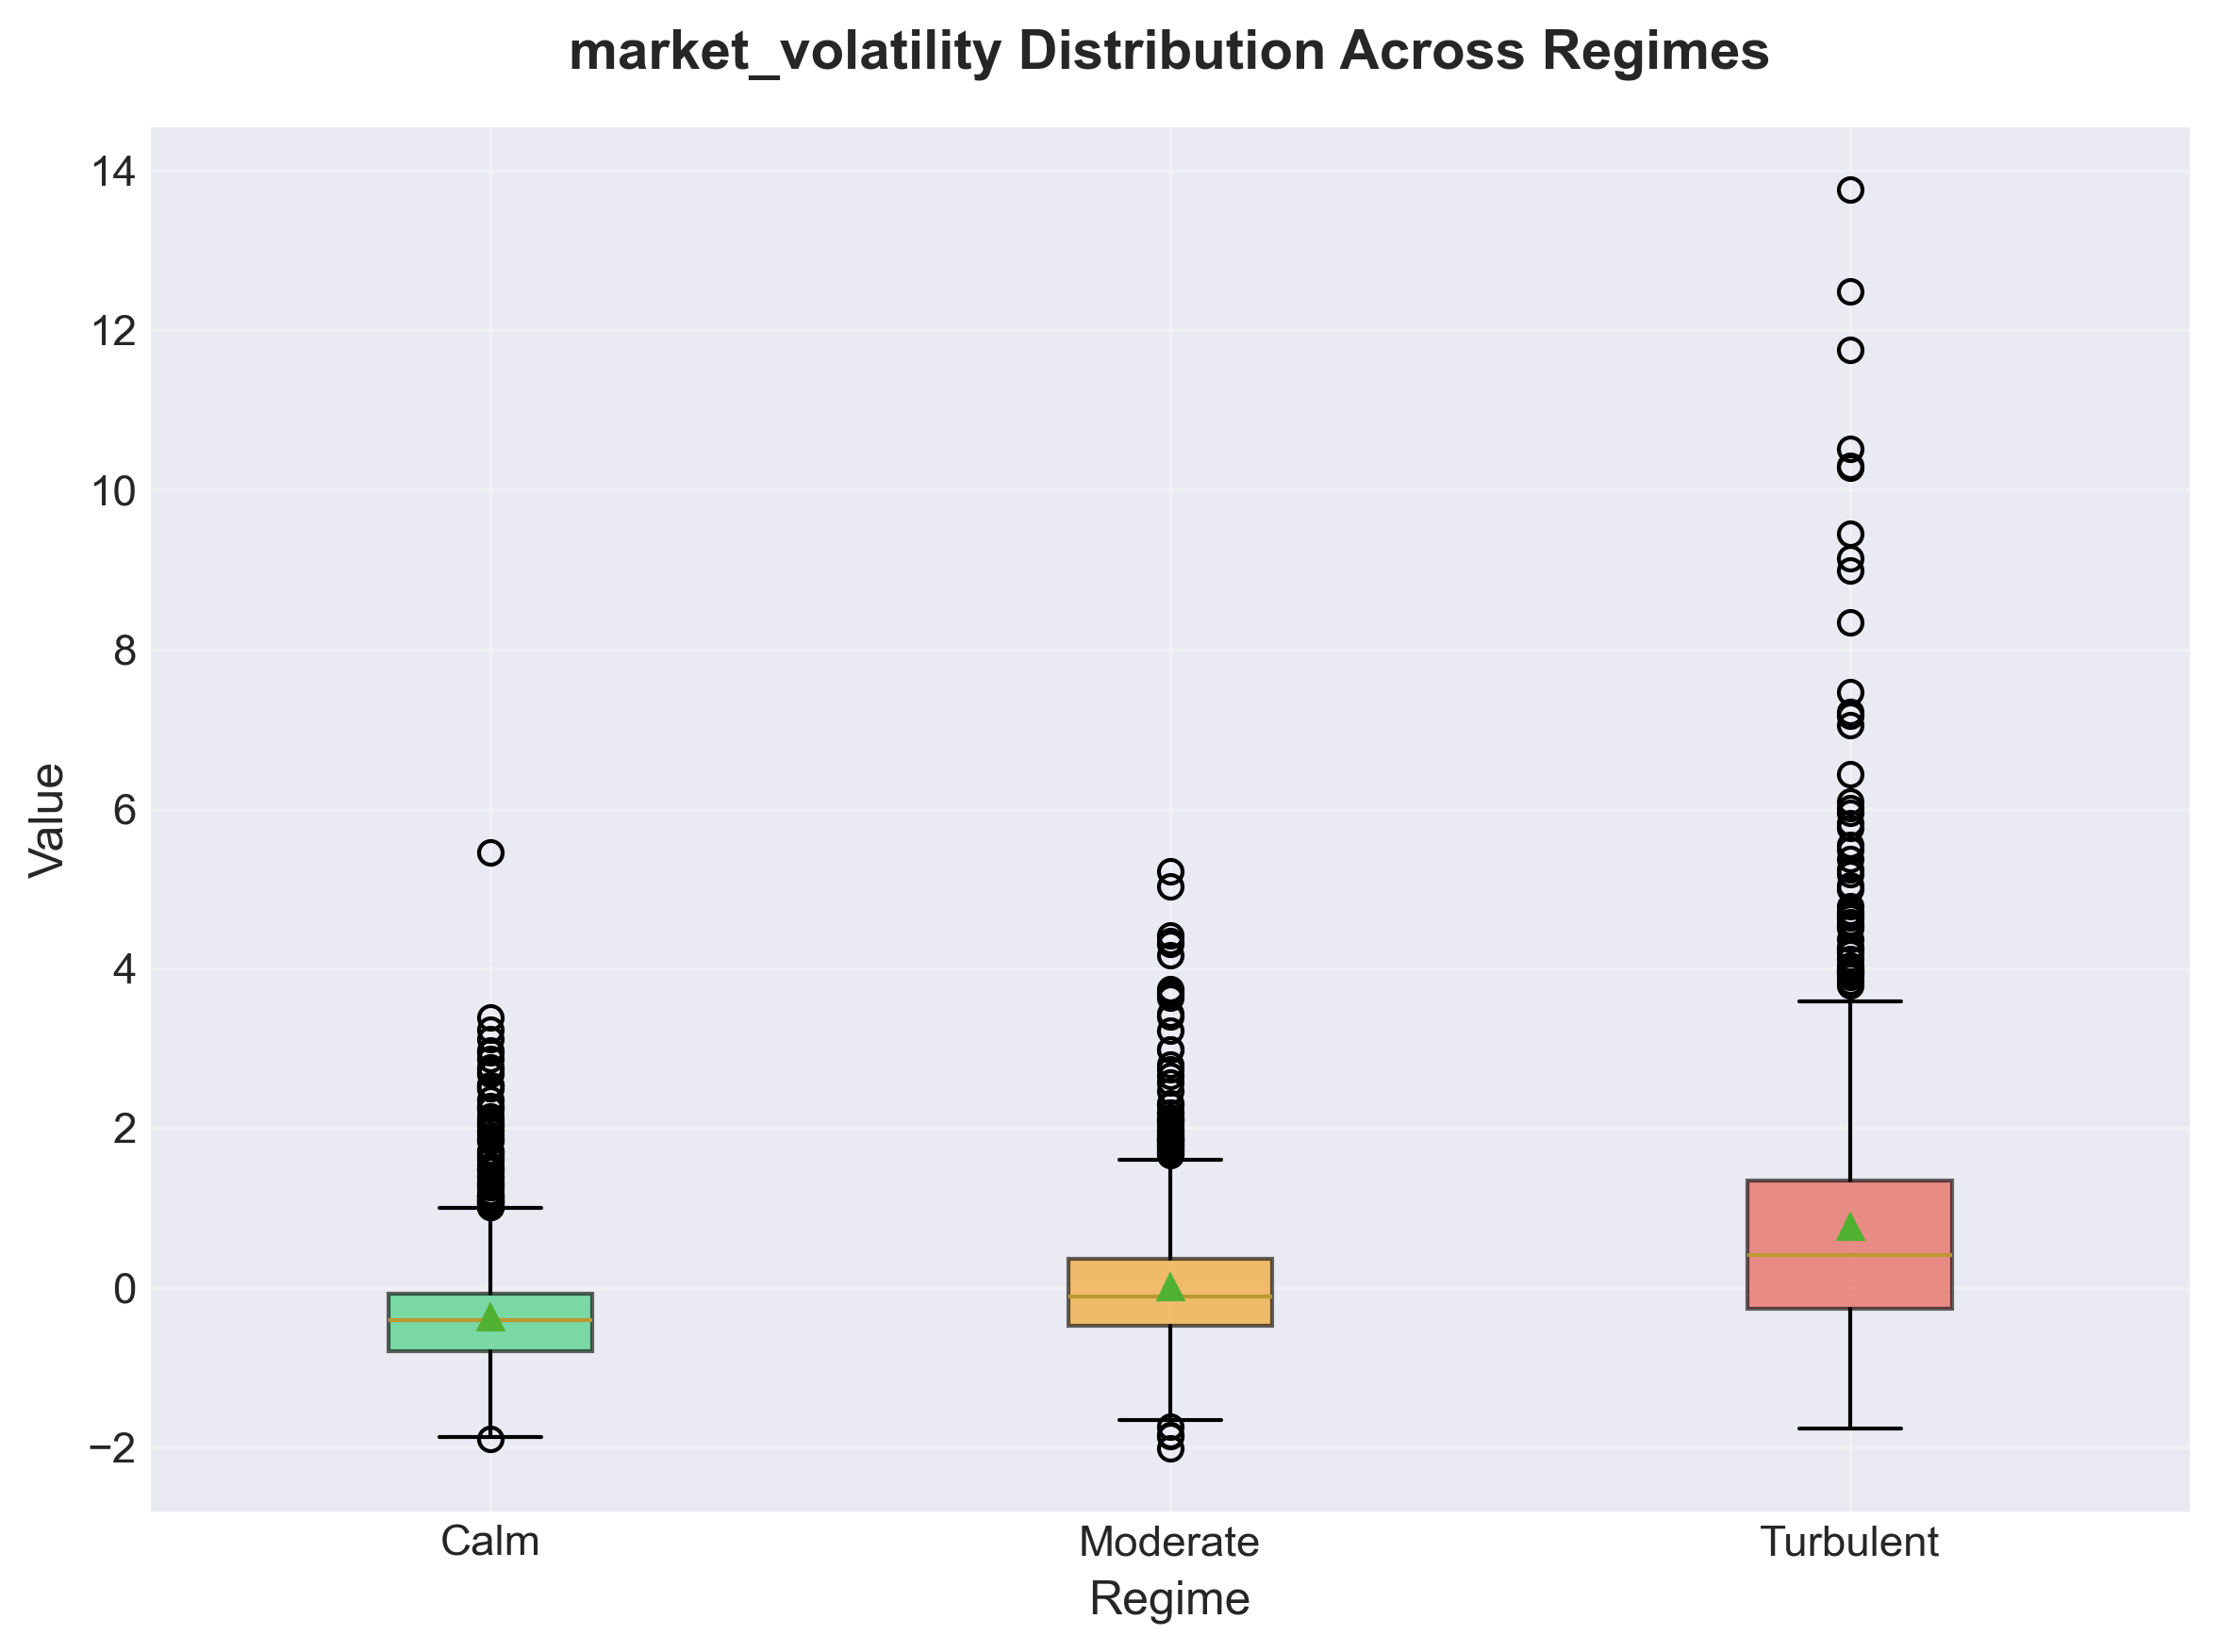

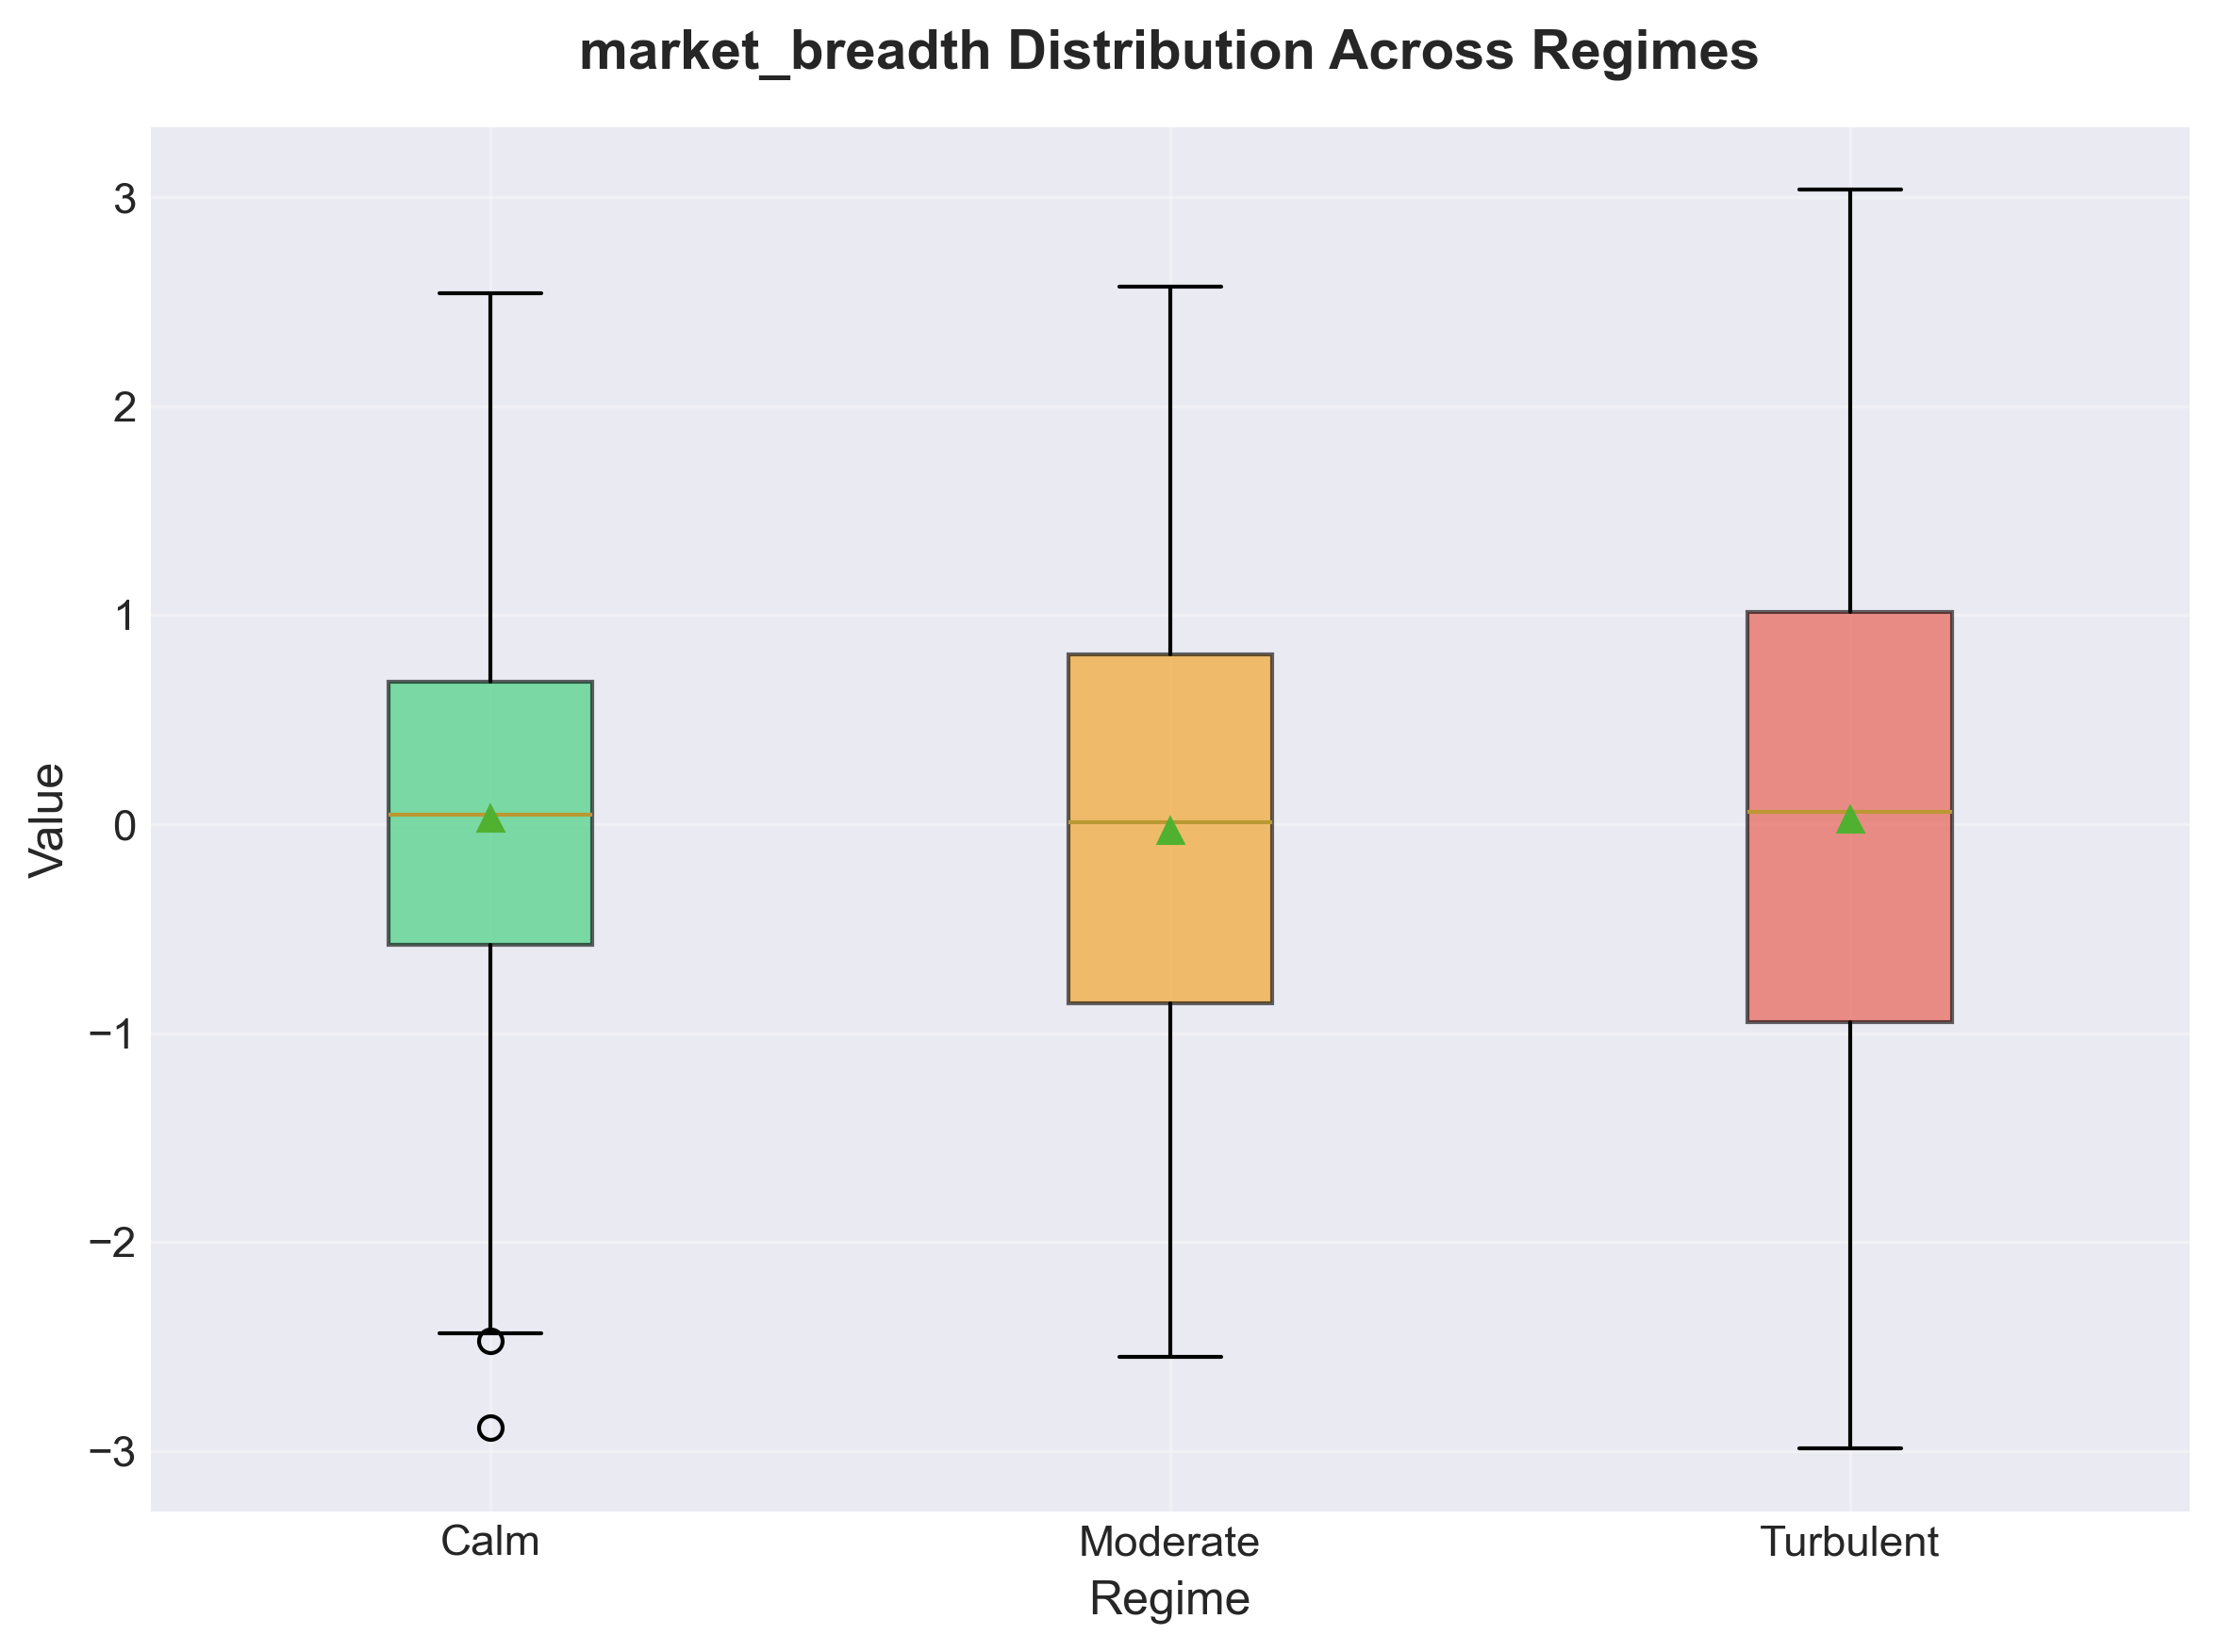

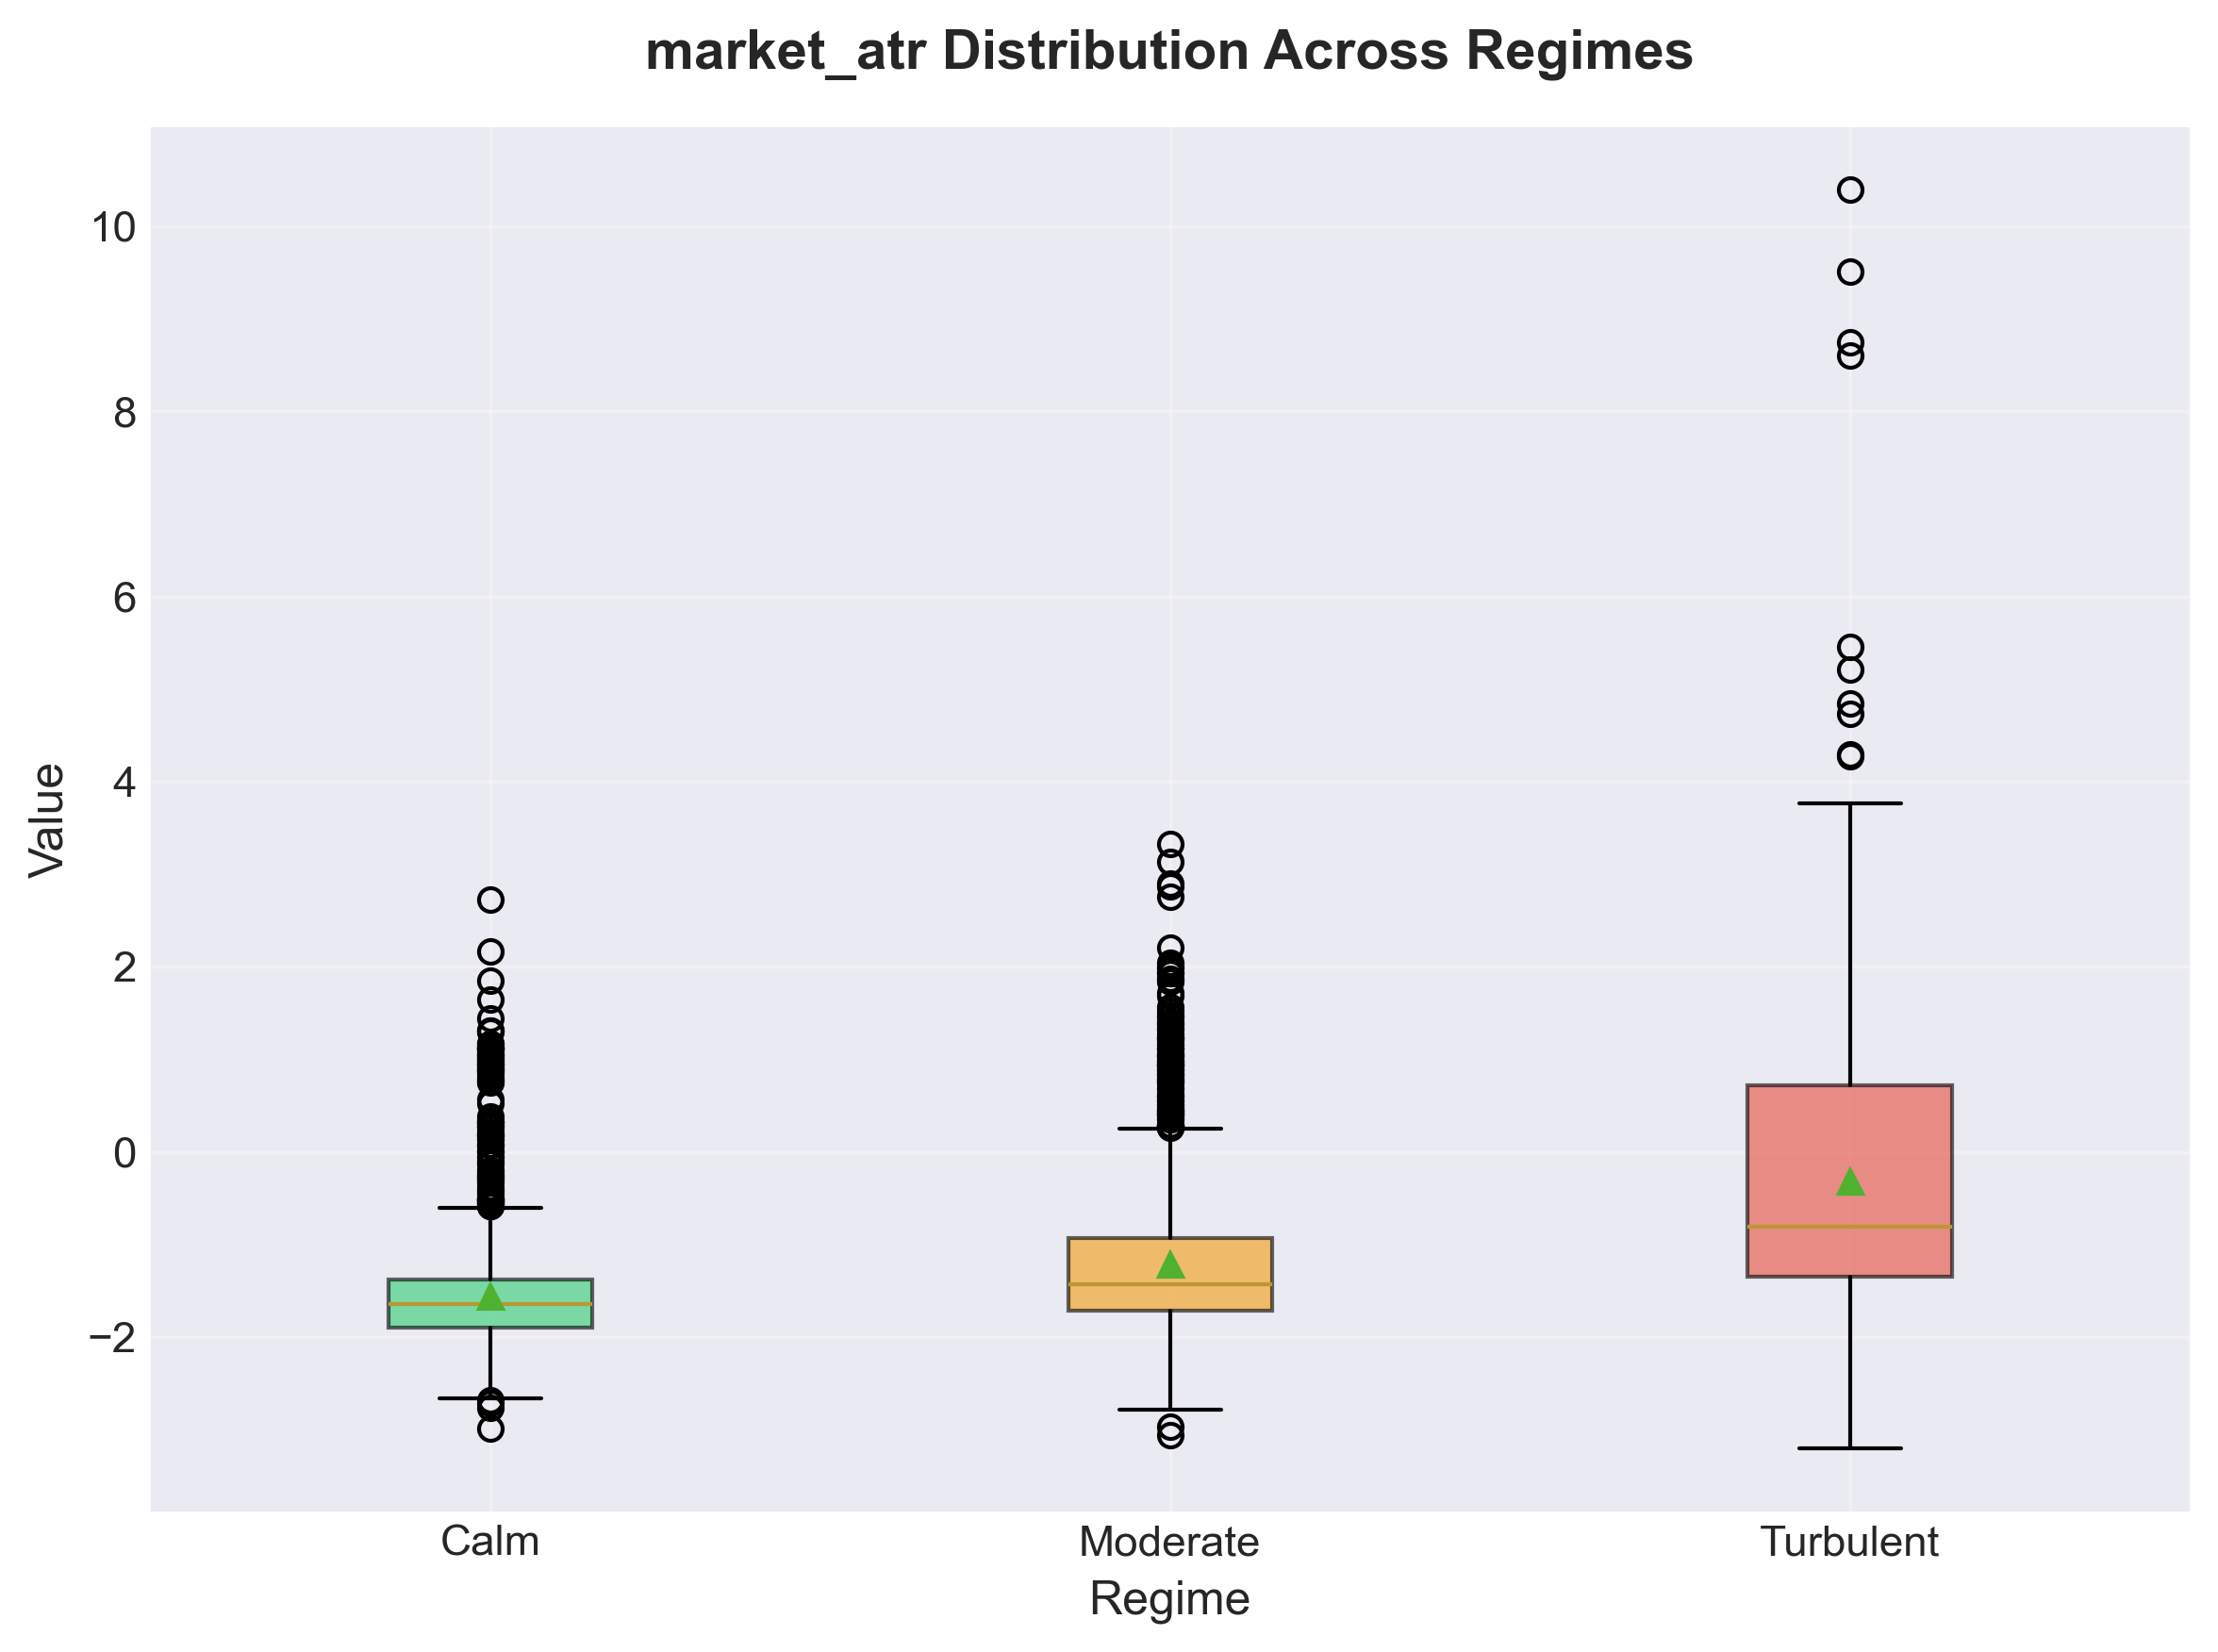

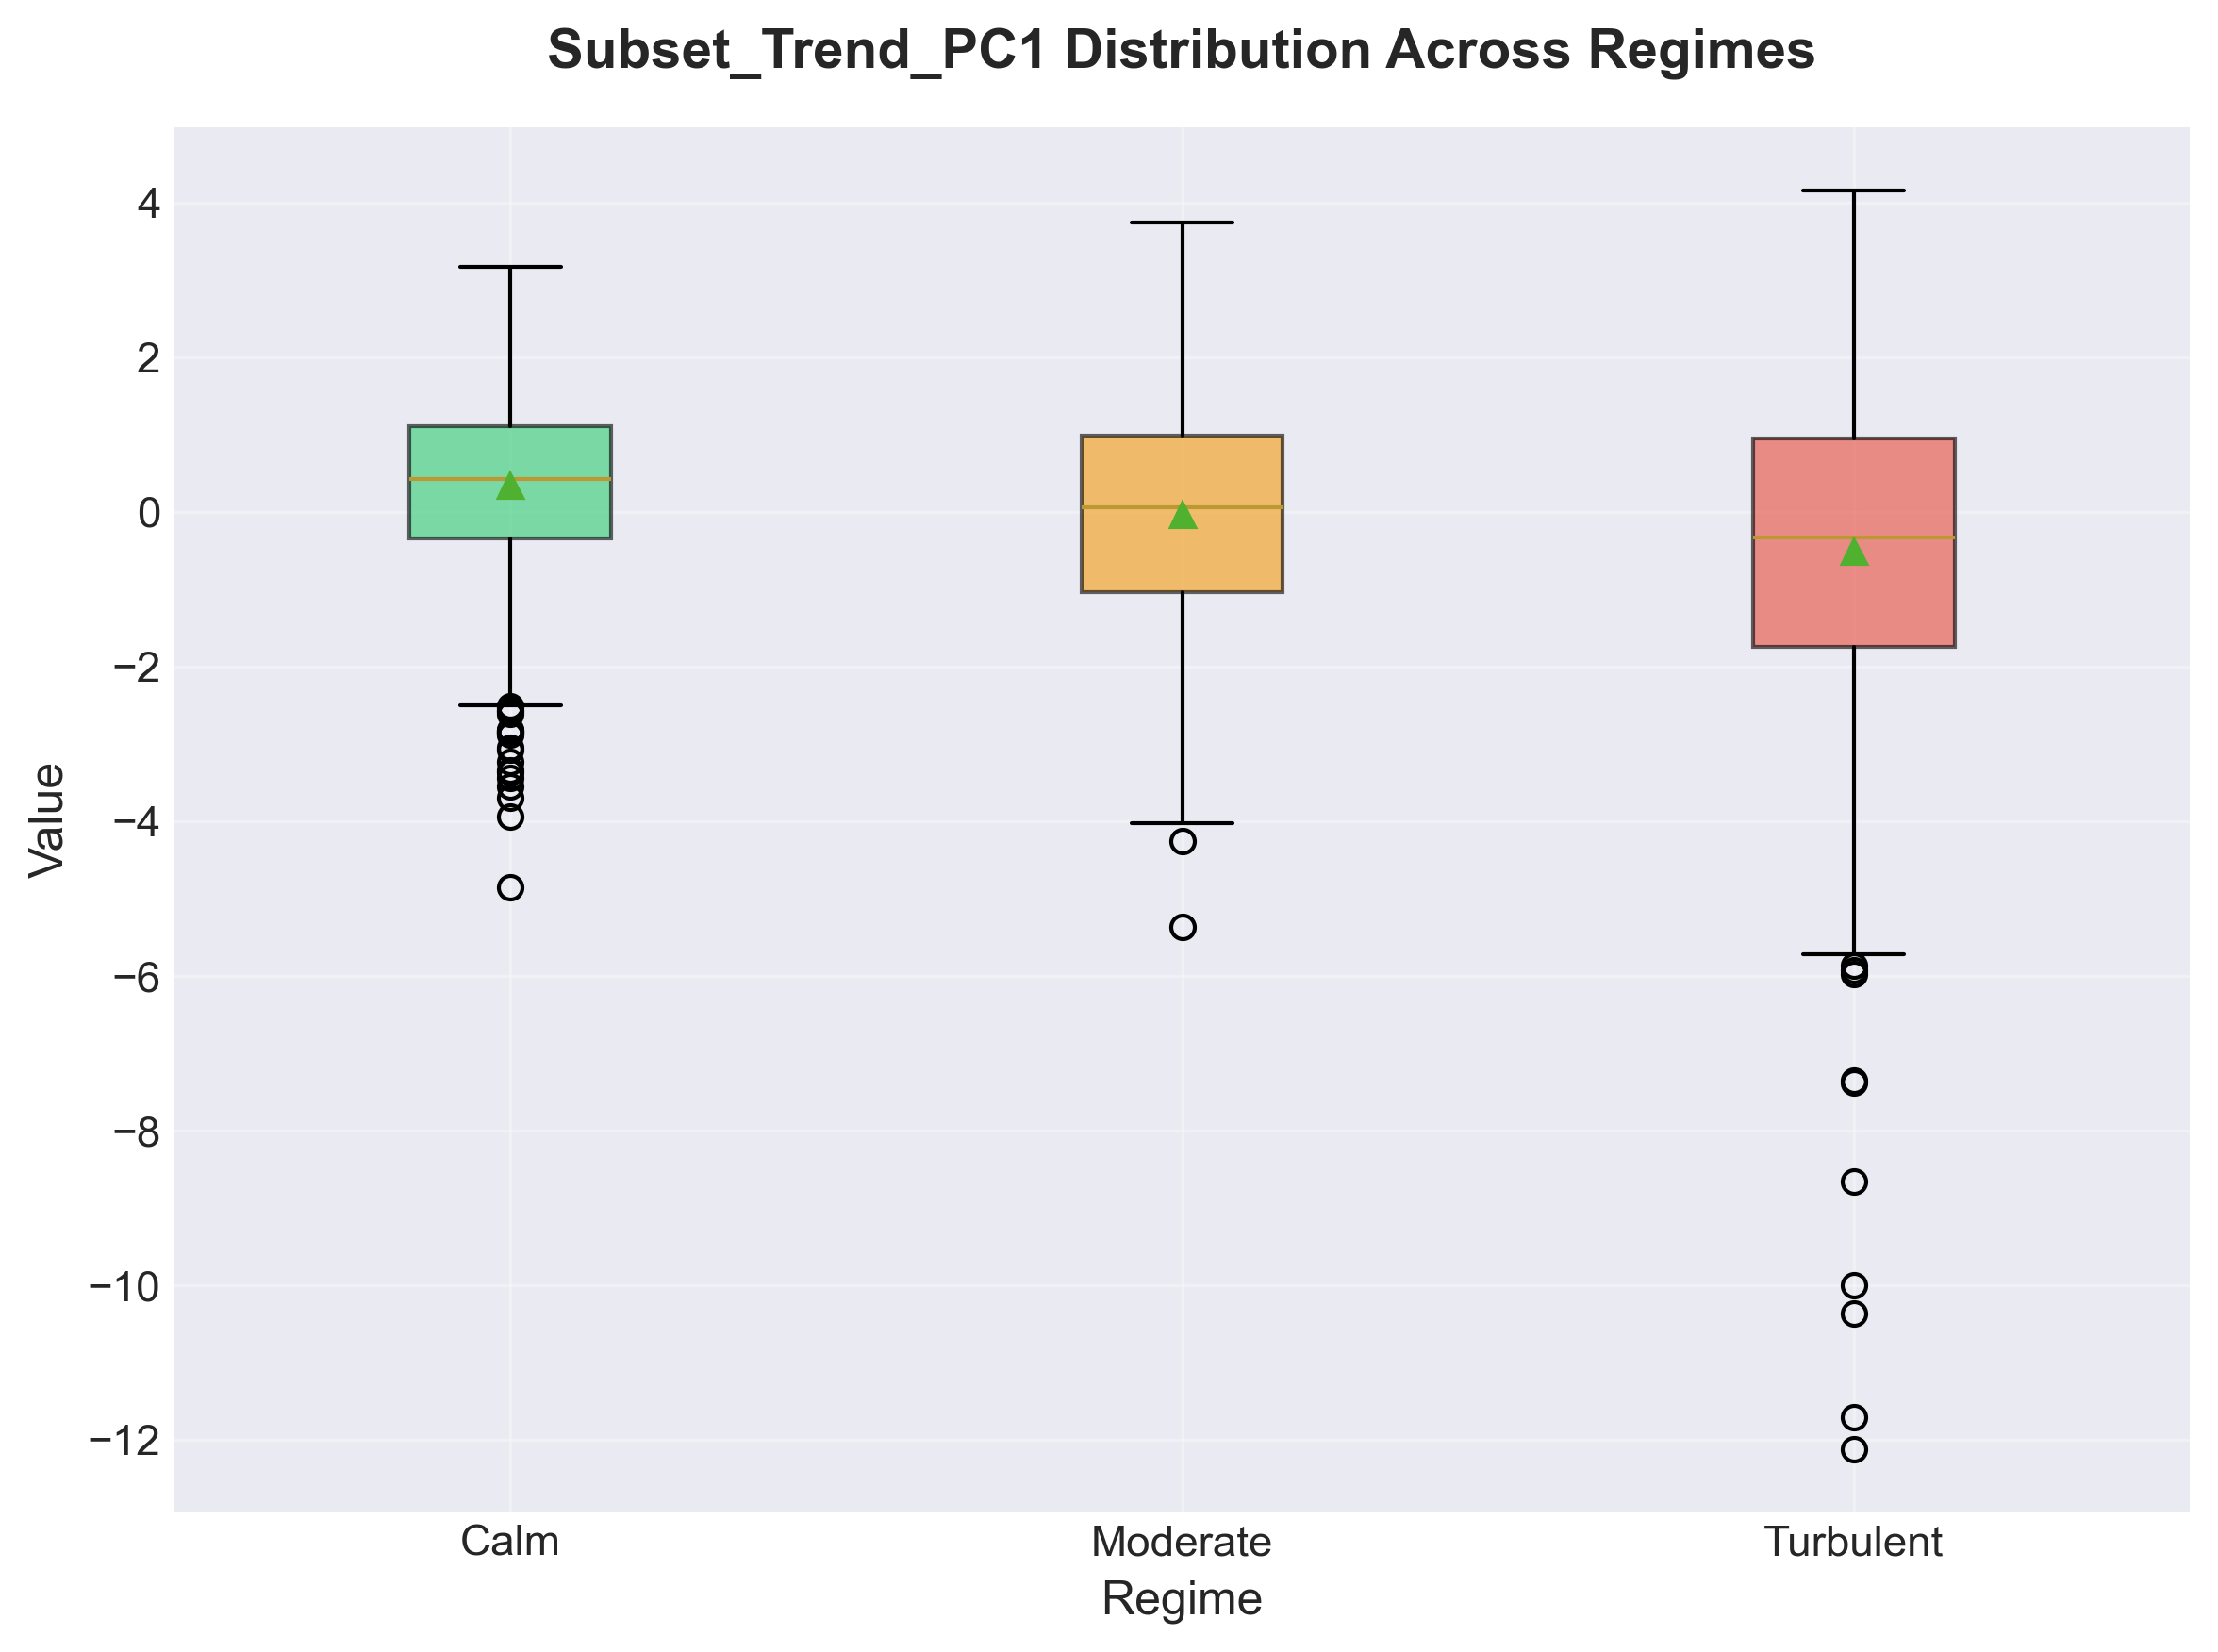

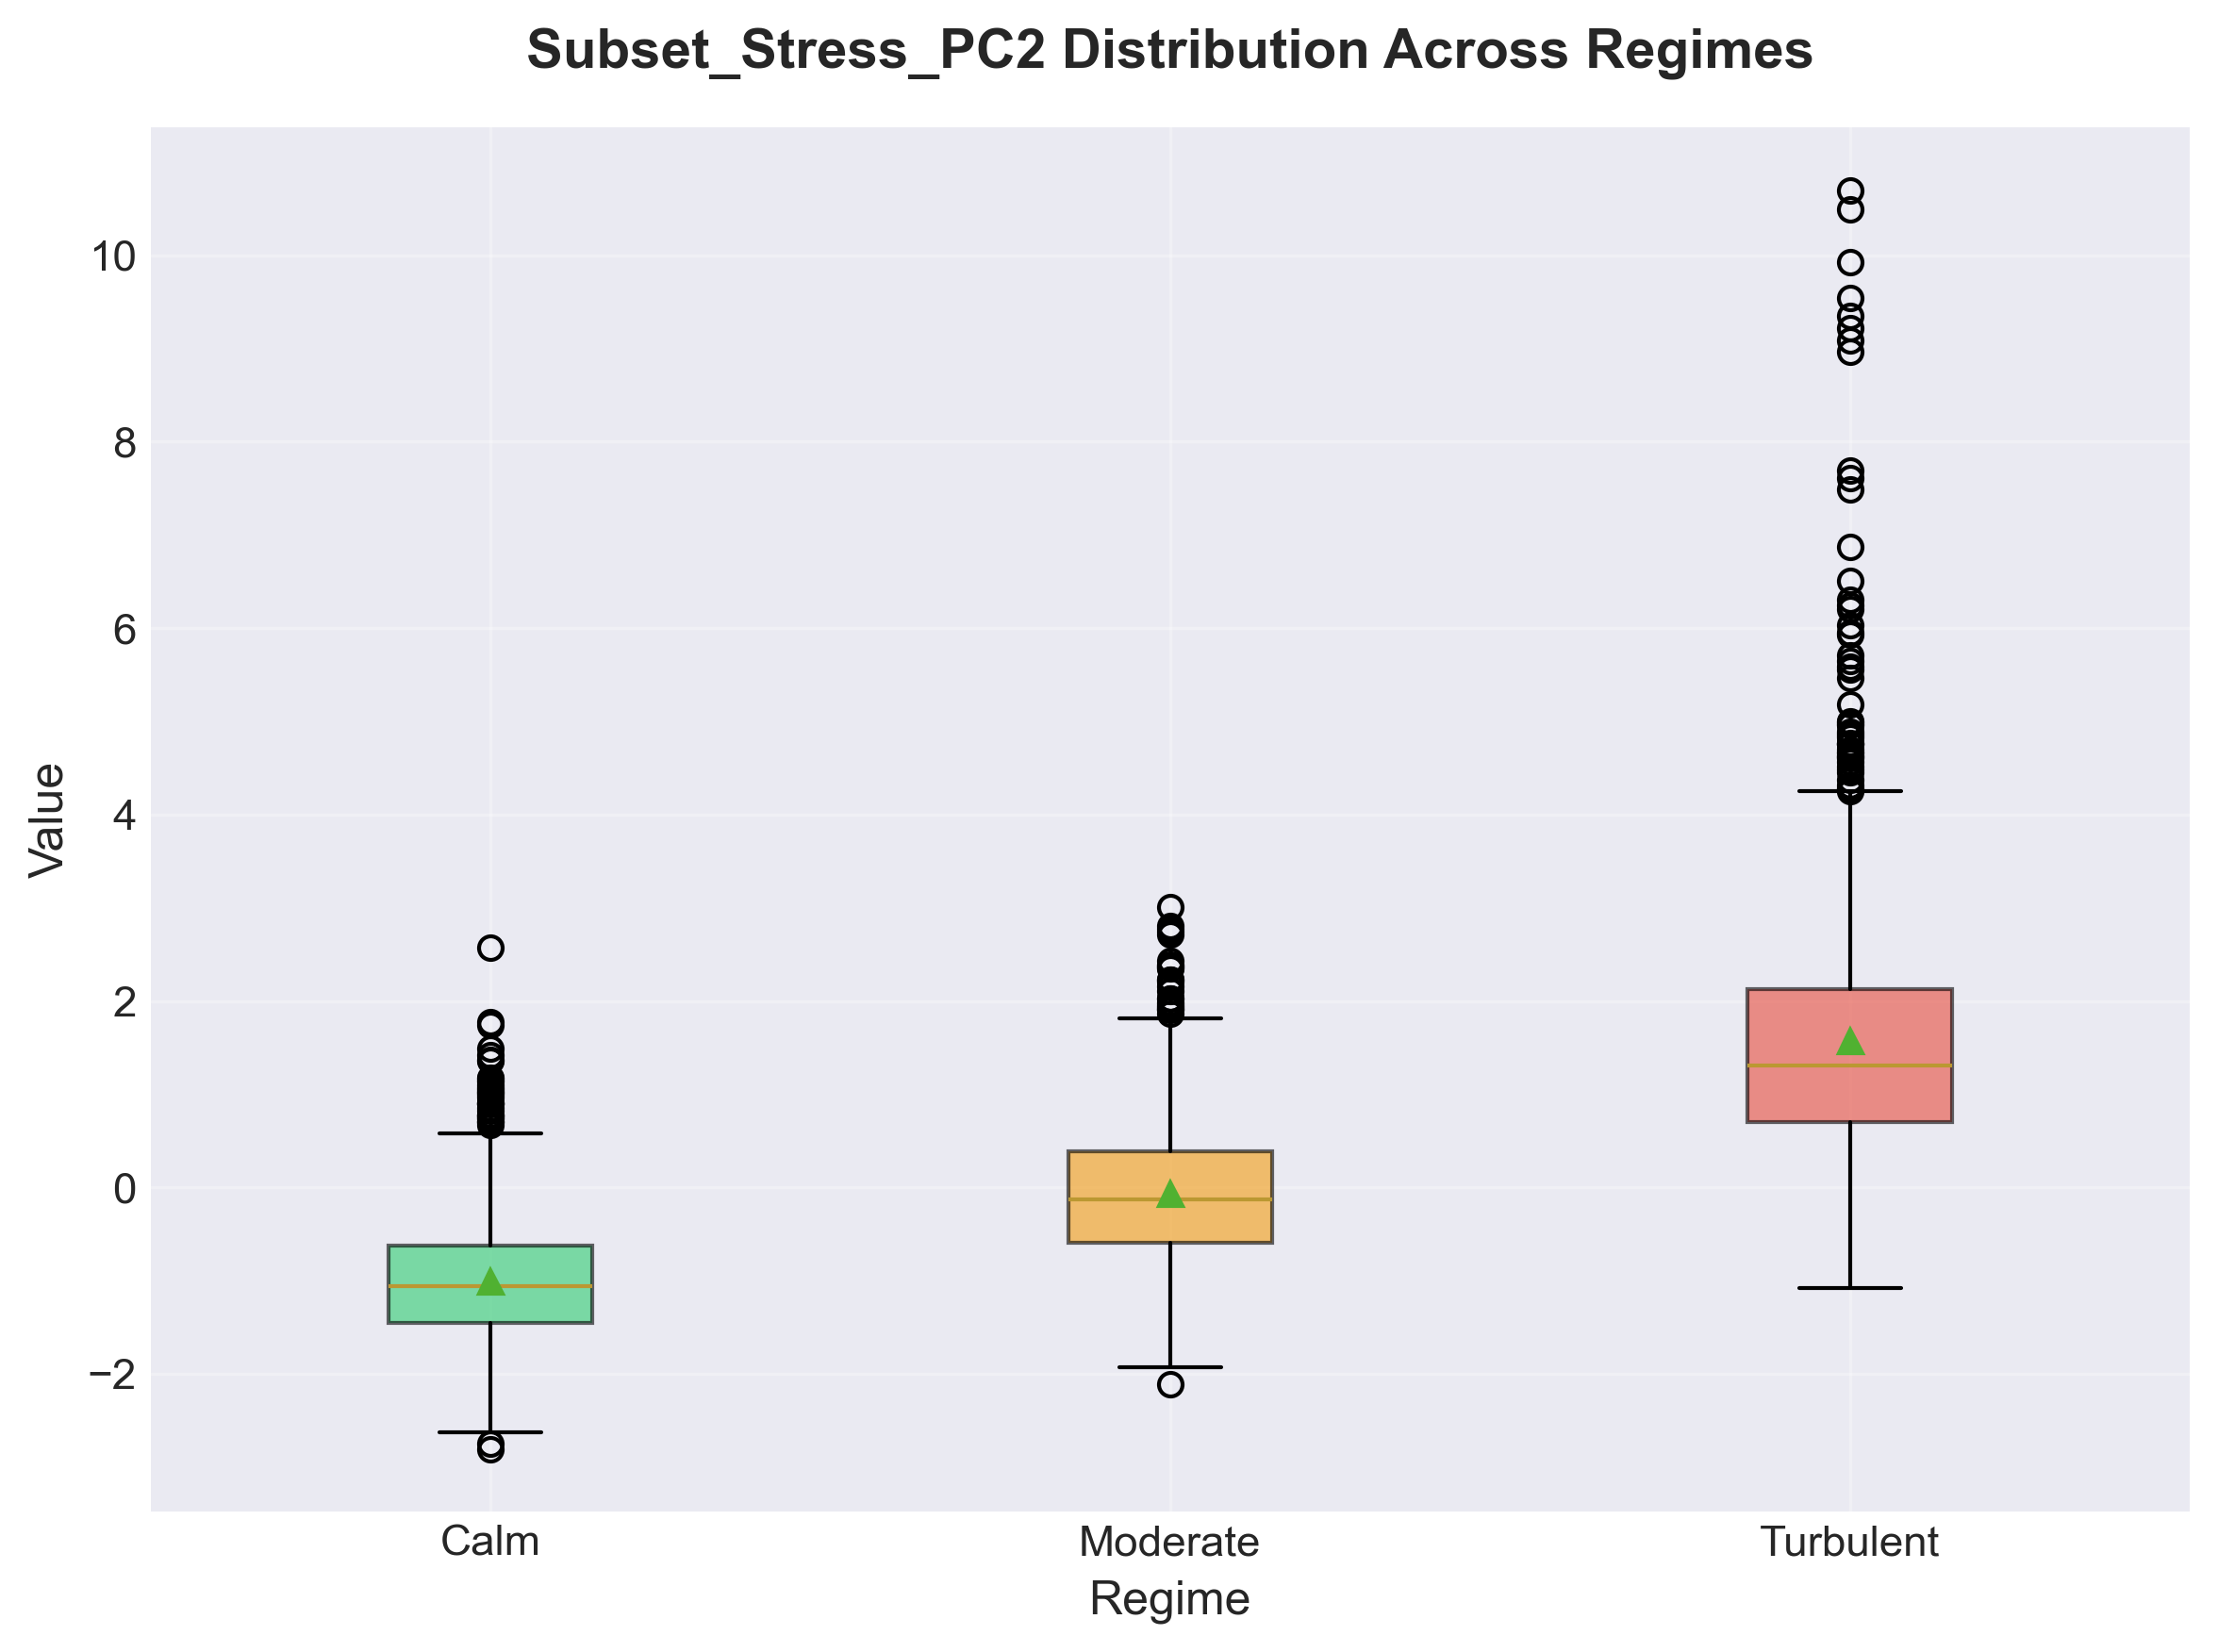

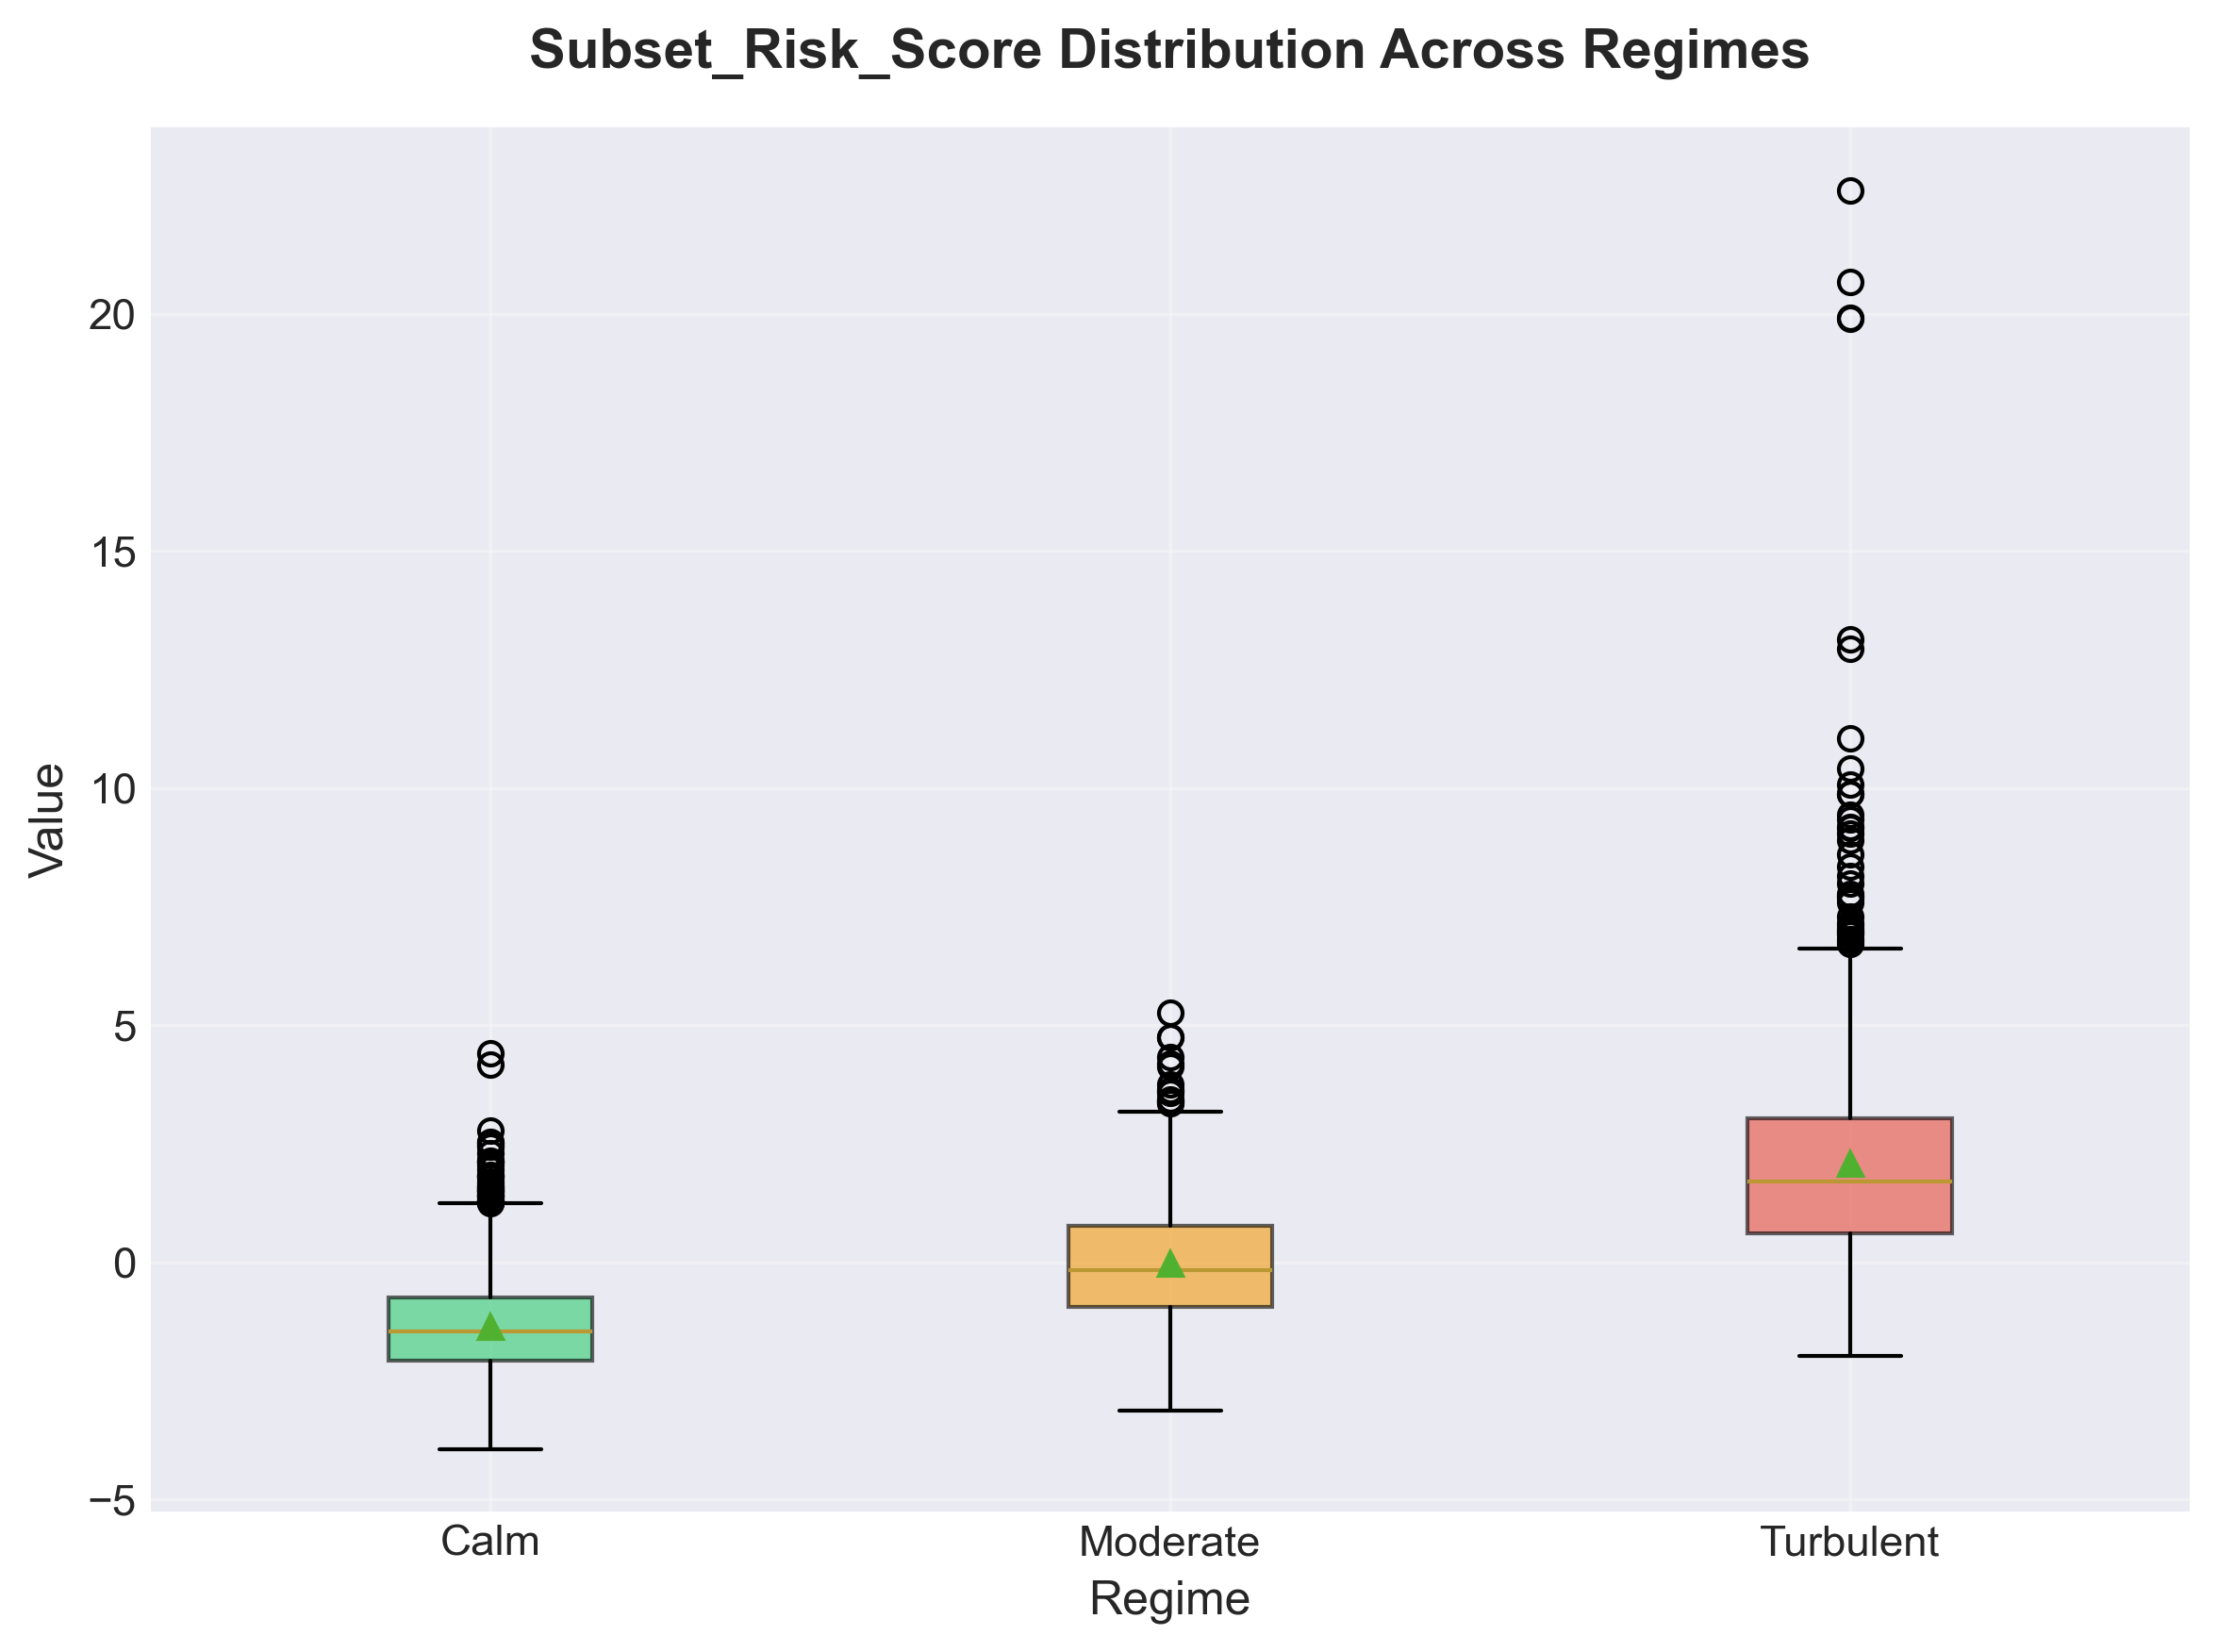

In [92]:
# Create individual boxplots for each indicator
n_indicators = len(INDICATOR_COLS)

# Create a separate figure for each indicator
for idx, indicator in enumerate(INDICATOR_COLS):
    # Create individual figure
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Prepare data for boxplot
    data_to_plot = [df[df['regime'] == r][indicator].dropna() for r in [0, 1, 2]]
    
    bp = ax.boxplot(data_to_plot, labels=[REGIME_LABELS[r] for r in [0, 1, 2]], 
                     patch_artist=True, showmeans=True)
    
    # Color boxes by regime
    for patch, regime_label in zip(bp['boxes'], [REGIME_LABELS[r] for r in [0, 1, 2]]):
        patch.set_facecolor(REGIME_COLORS[regime_label])
        patch.set_alpha(0.6)
    
    ax.set_title(f'{indicator} Distribution Across Regimes', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_xlabel('Regime', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    
    # Save individual plot
    boxplot_path = Path(f'../results/figures/regime_boxplot_{indicator.lower().replace(" ", "_")}.png')
    plt.savefig(boxplot_path, dpi=300, bbox_inches='tight')
    plt.show()

### Figure 2: Heatmap of Standardized Regime Characteristics


Saved heatmap figure to: ../results/figures/regime_heatmap.png


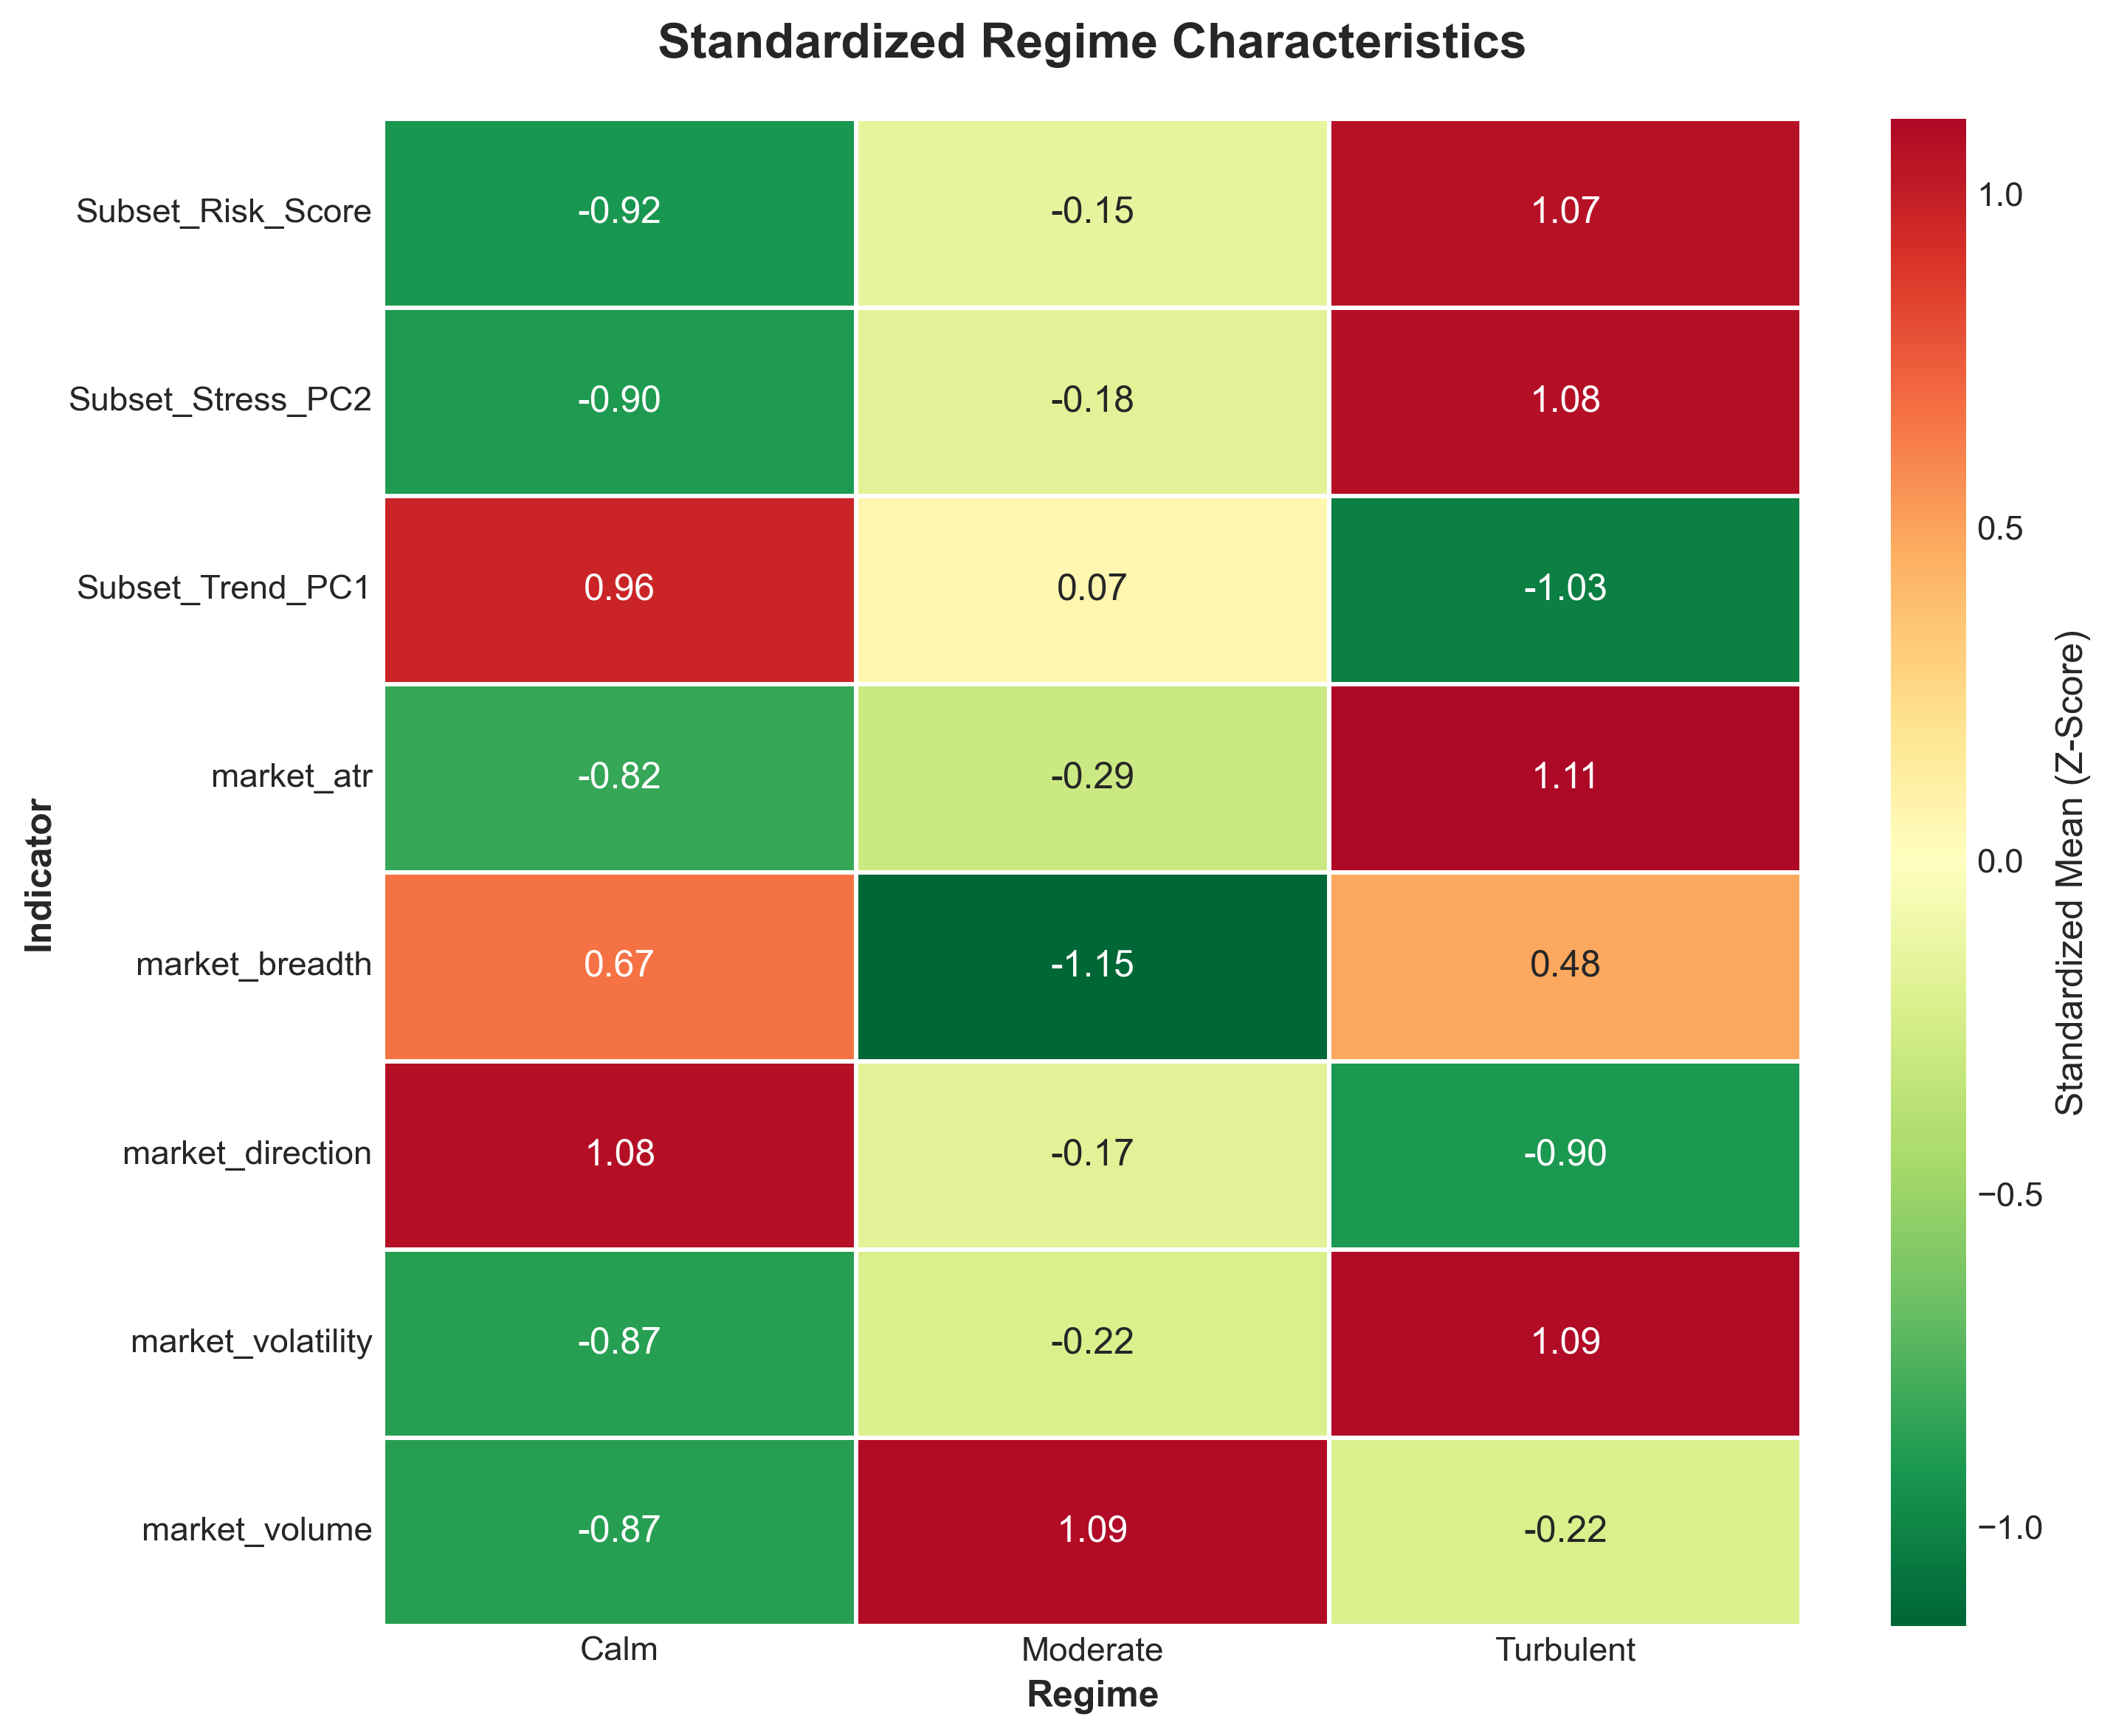

In [93]:
# Create heatmap of standardized means
heatmap_data = df_stats.pivot(index='indicator', columns='regime_label', values='mean')

# Standardize per indicator (z-score across regimes)
heatmap_data_std = heatmap_data.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# Reorder columns for consistency
heatmap_data_std = heatmap_data_std[['Calm', 'Moderate', 'Turbulent']]

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data_std, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            center=0, linewidths=1, cbar_kws={'label': 'Standardized Mean (Z-Score)'}, ax=ax)

ax.set_title('Standardized Regime Characteristics', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Regime', fontsize=12, fontweight='bold')
ax.set_ylabel('Indicator', fontsize=12, fontweight='bold')

plt.tight_layout()
heatmap_path = Path('../results/figures/regime_heatmap.png')
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
print(f"Saved heatmap figure to: {heatmap_path}")
plt.show()


### Figure 3: Regime Timeline


Saved timeline figure to: ../results/figures/regime_timeline.png


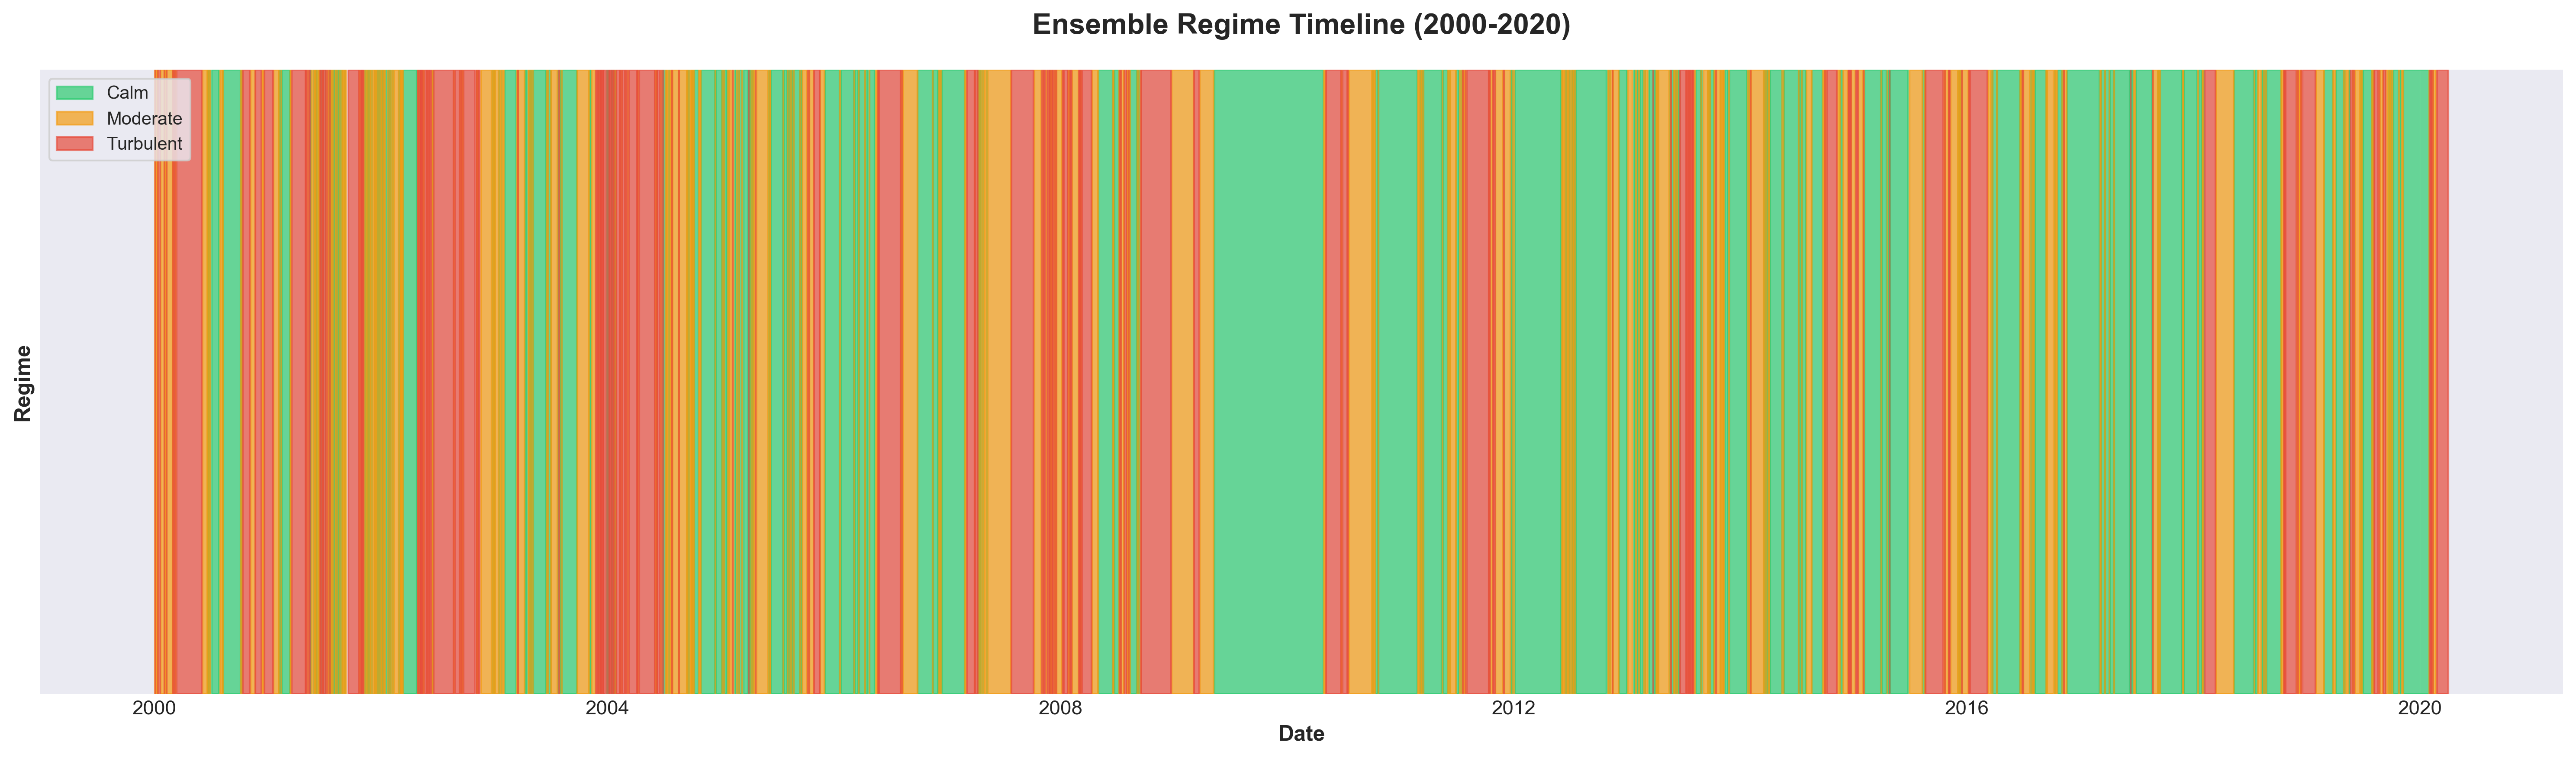

In [94]:
# Create timeline plot with colored regime bands
fig, ax = plt.subplots(figsize=(20, 6))

# Plot regime as colored bands
for regime in [0, 1, 2]:
    regime_label = REGIME_LABELS[regime]
    mask = df['regime'] == regime
    ax.fill_between(df.index, 0, 1, where=mask, 
                     color=REGIME_COLORS[regime_label], alpha=0.7, label=regime_label)

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Regime', fontsize=12, fontweight='bold')
ax.set_title('Ensemble Regime Timeline (2000-2020)', fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.legend(loc='upper left', fontsize=10, frameon=True)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
timeline_path = Path('../results/figures/regime_timeline.png')
plt.savefig(timeline_path, dpi=300, bbox_inches='tight')
print(f"Saved timeline figure to: {timeline_path}")
plt.show()

## 5. Transition Analysis


In [95]:
# Compute transition matrix
regimes = df['regime'].values
n_regimes = 3

# Count transitions
transition_counts = np.zeros((n_regimes, n_regimes))
for i in range(len(regimes) - 1):
    from_regime = regimes[i]
    to_regime = regimes[i + 1]
    transition_counts[from_regime, to_regime] += 1

# Normalize to get probabilities
transition_probs = transition_counts / transition_counts.sum(axis=1, keepdims=True)

# Create DataFrame
df_transitions = pd.DataFrame(
    transition_probs,
    index=[REGIME_LABELS[i] for i in range(n_regimes)],
    columns=[REGIME_LABELS[i] for i in range(n_regimes)]
)

# Save transition matrix
transitions_path = Path('../results/tables/regime_transitions.csv')
df_transitions.to_csv(transitions_path)


In [96]:
# Compute regime durations
regime_runs = []
current_regime = regimes[0]
current_duration = 1

for i in range(1, len(regimes)):
    if regimes[i] == current_regime:
        current_duration += 1
    else:
        regime_runs.append({'regime': current_regime, 'duration': current_duration})
        current_regime = regimes[i]
        current_duration = 1

# Add last run
regime_runs.append({'regime': current_regime, 'duration': current_duration})

df_runs = pd.DataFrame(regime_runs)
df_runs['regime_label'] = df_runs['regime'].map(REGIME_LABELS)

# Compute duration statistics
duration_stats = df_runs.groupby('regime_label')['duration'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('min', 'min'),
    ('max', 'max')
]).round(2)

# Reorder by regime
duration_stats = duration_stats.reindex(['Calm', 'Moderate', 'Turbulent'])

# Save durations
durations_path = Path('../results/tables/regime_durations.csv')
duration_stats.to_csv(durations_path)


### Figure 4: Transition Matrix and Duration Distributions


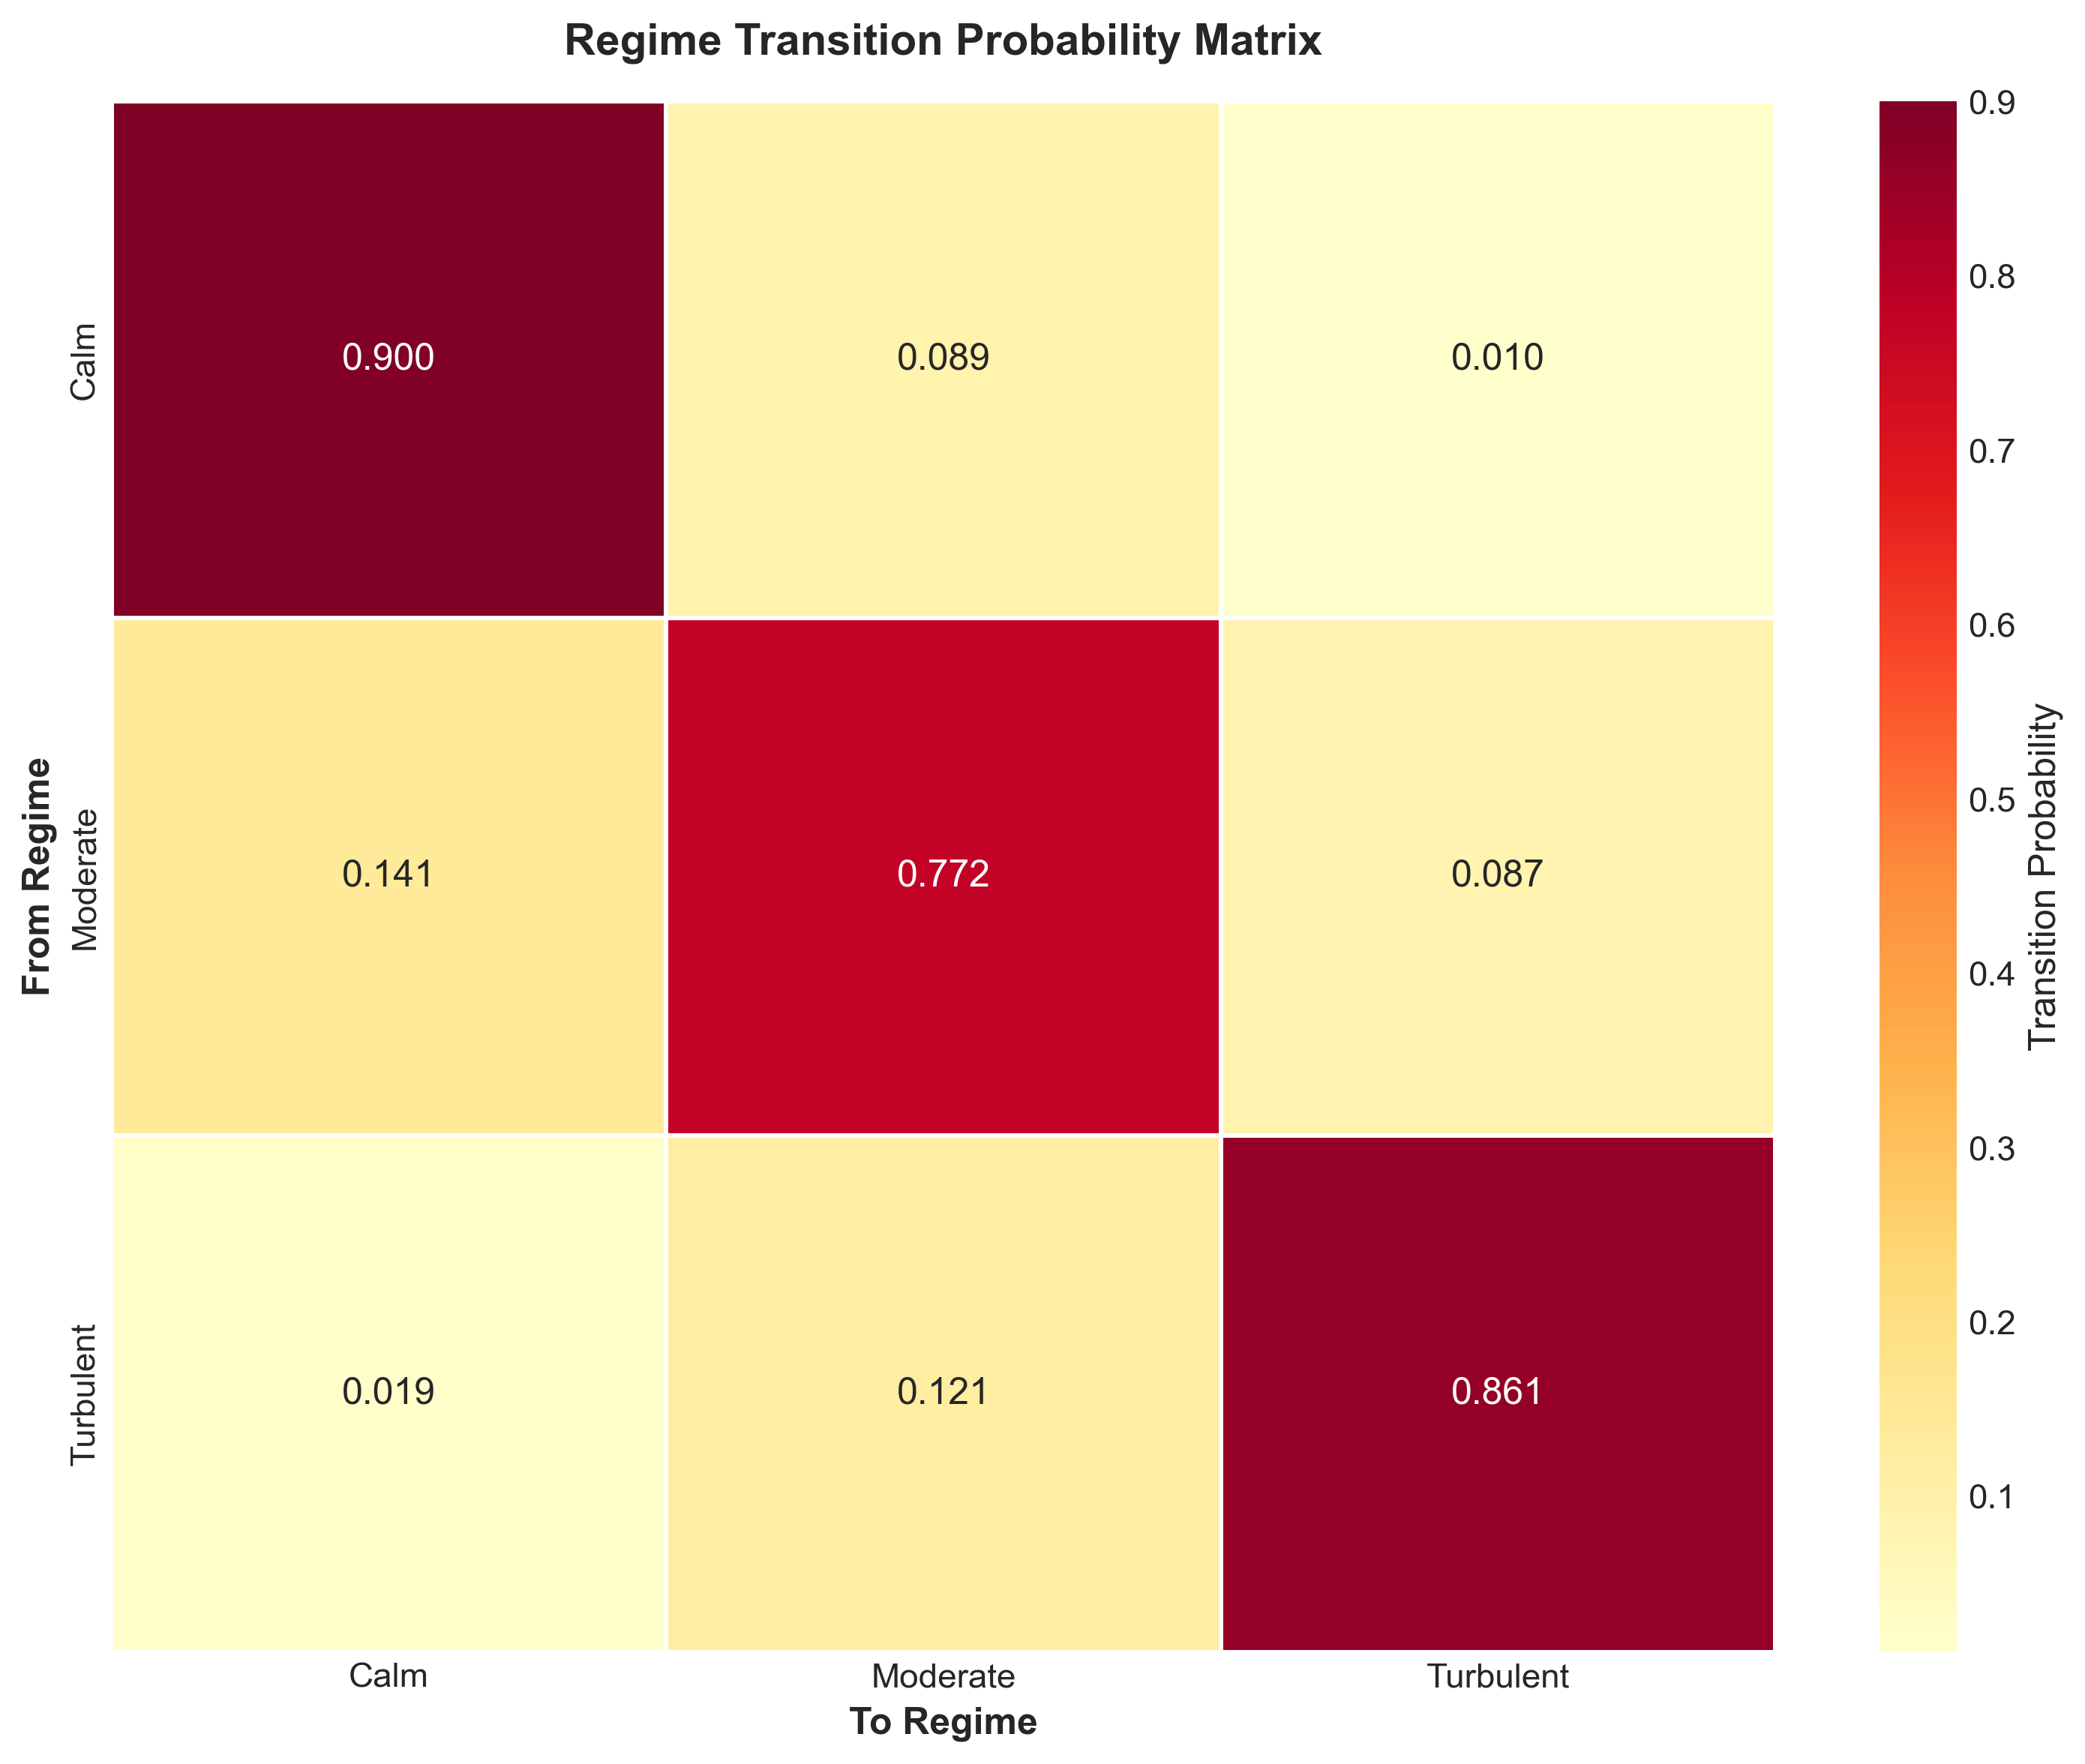

In [97]:
# Create transition matrix heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(df_transitions, annot=True, fmt='.3f', cmap='YlOrRd', 
            linewidths=1, cbar_kws={'label': 'Transition Probability'}, ax=ax)
ax.set_title('Regime Transition Probability Matrix', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('To Regime', fontsize=12, fontweight='bold')
ax.set_ylabel('From Regime', fontsize=12, fontweight='bold')

plt.tight_layout()
transitions_fig_path = Path('../results/figures/regime_transitions.png')
plt.savefig(transitions_fig_path, dpi=300, bbox_inches='tight')
plt.show()

## Summary


## Regime Characterization Summary

### Data Overview
Analyzed 5,094 trading days from January 2000 to April 2020 using 8 market indicators to characterize three distinct market regimes.

### Regime Distribution
The ensemble method identified three regimes based on market volatility and stress levels:
- **Calm**: Normal market conditions with low volatility
- **Moderate**: Transitional periods with elevated uncertainty  
- **Turbulent**: Crisis periods with high volatility (2008 financial crisis, COVID-19 crash, etc.)

### Statistical Validation
ANOVA tests confirm that the three regimes are statistically distinct. Out of 8 indicators, 7 show significant differences across regimes (p < 0.05).

The most significant indicators are:
- **Subset_Stress_PC2** (F=3101.84, p≈0) - best separator
- **Subset_Risk_Score** (F=2113.11, p≈0) - strong classifier
- **market_atr** (F=723.35, p=3.19e-277) - captures volatility well
- **market_volatility** (F=501.00, p=2.39e-199) - identifies turbulent periods

### Key Takeaways
The low p-values confirm that our regime classification captures genuinely distinct market states. Stress and risk metrics turn out to be the most powerful discriminators, while traditional volatility measures like ATR and realized volatility are also highly effective at identifying turbulent periods.